## This Notebook gives an example on how to perform differential gene expression analysis of different readouts e.g., Inclusions and CAGs (Figure 7 and Supplementary Figures 17-18 in the manuscript)

In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import glob,os
import anndata
import scanpy.external as sce
import seaborn as sns
from scipy.stats import pearsonr
from adjustText import adjust_text
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

In [2]:
concatenated_adata_f_AGG=sc.read_h5ad('adata/Dryad/adata_AGG_CAG.h5ad')

In [3]:
def plot_volcano(adata, group='Agg', log_fold_change_col='logfoldchanges', p_value_col='pvals_adj', group_true_label='True', group_false_label='False'):
    log_fold_changes = adata.uns['rank_genes_groups'][log_fold_change_col][group_true_label]
    p_values = adata.uns['rank_genes_groups'][p_value_col][group_true_label]
    gene_names = adata.uns['rank_genes_groups']['names'][group_true_label]

    #colors = np.where(np.isin(gene_names, data_c_p_gn), 'orange', 'grey')  # first layer
    #colors = np.where(np.isin(gene_names, data_c_n_gn), 'blue', colors)    # overwrite if match
    #colors = np.where(np.isin(gene_names, data_d_gn), 'red', colors) 

    colors = np.where(((log_fold_changes) > 0.75)  &  (p_values < 0.05), 'lightcoral', 'grey')
    colors = np.where(((log_fold_changes) < -0.75) &  (p_values < 0.05)| (-np.log10(p_values) > 25), 'lightblue', colors)

    edc=np.where(((log_fold_changes) >0.75)  &  (p_values < 0.05), 'red', 'grey')
    edc=np.where(((log_fold_changes) < -0.75) &  (p_values < 0.05)| (-np.log10(p_values) > 25), 'blue', edc)
    
    plt.figure(figsize=(10, 8))
    
    plt.scatter(log_fold_changes, -np.log10(p_values), c=colors, edgecolor=edc, alpha=0.7)
    #plt.scatter(log_fold_changes, -np.log10(p_values), c=colors, alpha=0.7)
    
    significant_genes_indices = np.where(((np.abs(log_fold_changes) > 0.75) & (p_values < 0.05)) | (-np.log10(p_values) > 25))[0]
    
    annotations = []
    for i in significant_genes_indices:
       text = plt.text(log_fold_changes[i], -np.log10(p_values)[i], gene_names[i], fontsize=15, color='black')
       annotations.append(text)
    
    plt.axhline(y=-np.log10(0.05), color='grey', linestyle='--', linewidth=1)
    plt.axvline(x=0, color='grey', linestyle='--', linewidth=1)

    # Add labels and title
    plt.style.use('default')

    plt.xlabel('Log2 Fold Change', fontsize=18)
    plt.ylabel('-log10(p-value)', fontsize=18)
    plt.title('', fontsize=16)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.xlim(-2.5,2.5)
    plt.ylim(-1, 39)

    #red_patch = plt.Line2D([0], [0], marker='o', color='b', markerfacecolor='red', markersize=10, label='Significant')
    #blue_patch = plt.Line2D([0], [0], marker='o', color='b', markerfacecolor='blue', markersize=10, label='Non-significant')

    adjust_text(annotations, arrowprops=dict(arrowstyle="->", color='black'))

    plt.show()
    significant_genes = gene_names[significant_genes_indices]
    return list(significant_genes)


In [4]:
#Estimated Mean CAG

concatenated_adata_f_AGG.obs['CAG_length'] = [
    (cag_level - 0.0464) / 0.0024 if batch == 'Aug' else (cag_level - 0.0462) / 0.003
    for cag_level, batch in zip(concatenated_adata_f_AGG.obs['CAG'], concatenated_adata_f_AGG.obs['batch'])
]

In [5]:
wt_allele = {
    "C1": 30, "C3": 19, "C4": 19, "C5": 17,
    "H1": 22, "H2": 20, "H3": 19, "H4": 20, "H5": 19
}

In [6]:
#Estimated Mutant CAG

for pt in concatenated_adata_f_AGG.obs['patient'].unique():
    if pt in wt_allele:
        mask = concatenated_adata_f_AGG.obs['patient'] == pt
        concatenated_adata_f_AGG.obs.loc[mask, "CAG_mut"] = (
            concatenated_adata_f_AGG.obs.loc[mask, "CAG_length"] * 2 - wt_allele[pt]
        )

In [7]:
for pt in concatenated_adata_f_AGG.obs['patient'].unique():
    df = concatenated_adata_f_AGG[concatenated_adata_f_AGG.obs['patient'] == pt]
    print(f'{pt} CAG level: {np.mean(df.obs["CAG_mut"])}')

H1 CAG level: 49.54375806037704
H2 CAG level: 44.05922947150206
H4 CAG level: 55.91727695884768
C1 CAG level: 15.112511301120255
C3 CAG level: 21.81630464126221
H3 CAG level: 54.14808860076721
H5 CAG level: 58.86483817714501
C4 CAG level: 18.989591508764796
C5 CAG level: 21.096554912708083


In [8]:
concatenated_adata_f_AGG.obs['Expansion'] = concatenated_adata_f_AGG.obs['CAG_mut'] >= 150
concatenated_adata_f_AGG.obs['Expansion'] = concatenated_adata_f_AGG.obs['Expansion'].apply(lambda x: True if x else False)

In [9]:
concatenated_adata_f_AGG.obs['Expansion_250'] = concatenated_adata_f_AGG.obs['CAG_mut'] >= 250
concatenated_adata_f_AGG.obs['Expansion_250'] = concatenated_adata_f_AGG.obs['Expansion'].apply(lambda x: True if x else False)

In [10]:
bad_genes = ['AKT3', 'ANK3', 'APLP2', 'ARHGEF11', 'ATP8A2', 'C2CD5', 'CACNA1E', 'CADPS', 'CAMK2B', 'CEP290', 'CNOT6', 'CYFIP2', 'CYP2C8', 'DLGAP4',
             'EIF4G3', 'EPB41L1', 'ERC2', 'FAM193A', 'FKBP15', 'HP1BP3', 'ICA1', 'IMMT', 'IQCB1', 'KALRN', 'KCNQ2', 'KIF3A', 'KMT2C', 'MADD', 'MARK3',
             'MNAT1', 'NCAM1', 'NFIX', 'PACRGL', 'PDE2A', 'PLEKHA1', 'PLEKHA5', 'POLDIP3', 'PPP6R3', 'PRUNE2', 'PTPRD', 'PTPRT', 'RAP1GAP', 'RAPGEF4',
             'RAPGEF6', 'RNASET2', 'SCN1A', 'SETD5', 'SH3KBP1', 'SHISA9', 'STMN2', 'STXBP1', 'SYNE1', 'SYT7', 'TRAPPC12', 'TRRAP', 'UNC13A', 'UNC79', 
             'UQCRC2', 'VWA8', 'WHSC1L1', 'ZNF138', 'ZNF292']

In [11]:
all_genes = list(concatenated_adata_f_AGG.var.index)

In [12]:
good_genes = [gn for gn in all_genes if gn not in bad_genes]
len(good_genes)

1066

In [13]:
ign = [list(concatenated_adata_f_AGG.var.index).index(gnm) for gnm in good_genes]
ign = np.array(ign)
concatenated_adata_f_AGG=concatenated_adata_f_AGG[:, ign].copy()
concatenated_adata_f_AGG.obsm['X_raw']=concatenated_adata_f_AGG.obsm['X_raw'][:, ign]

In [14]:
concatenated_adata_f_AGG

AnnData object with n_obs × n_vars = 185721 × 1066
    obs: 'volm', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'CAG', 'nHTT', 'vol_nuc', 'sample', 'HD', 'patient', 'batch', 'cluster_names', 'Agg', 'Agg_bright', 'Agg_vol', 'Agg_x', 'Agg_y', 'Agg_z', 'Agg_dist', 'cluster_general', 'lipo', 'm_gamma', 'v_gamma', 'm_h3k9', 'm_h3k27', 'CAG_length', 'CAG_mut', 'Expansion', 'Expansion_250'
    obsm: 'X_pca', 'X_pca_harmony', 'X_raw', 'X_spatial', 'X_umap'

In [15]:
def siglogfc(data, condition='True'):
    logfc = pd.Series(
        data.uns['rank_genes_groups']['logfoldchanges'][condition],
        index=data.uns['rank_genes_groups']['names'][condition]
    )
    p_values = pd.Series(
        data.uns['rank_genes_groups']['pvals'][condition],
        index=data.uns['rank_genes_groups']['names'][condition]
    )
    return logfc, p_values

In [16]:
HD_adata = concatenated_adata_f_AGG[concatenated_adata_f_AGG.obs['HD']==True].copy()
HD_adata.obs['Agg'] = HD_adata.obs['Agg'].fillna(False).astype('bool').astype('category')

In [17]:
HD_Exc = HD_adata[HD_adata.obs['cluster_general']=='Excitatory Neurons'].copy()

In [18]:
HD_Exc.obs['HD'] = HD_Exc.obs['HD'].fillna(False).astype('bool').astype('category')

In [19]:
HD_Exc_5=HD_Exc[HD_Exc.obs['CAG']>0].copy()
adata = HD_Exc_5.copy() 

In [20]:
##################################################
#### SUPPLEMENTARY FIGURE 17A: Bulk Differential Expression Analysis CAG >250 vs <50
##################################################

In [21]:
adata.obs['Condition'] = '<50'  # default

adata.obs.loc[(adata.obs['CAG_mut']>50) & (adata.obs['CAG_mut']<=150), 'Condition'] = '50-150'
adata.obs.loc[(adata.obs['CAG_mut']>150) & (adata.obs['CAG_mut']<=250), 'Condition'] = '150-250'
adata.obs.loc[(adata.obs['CAG_mut']>250), 'Condition'] = '>250'

adata.obs['Condition'] = adata.obs['Condition'].astype('category')

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


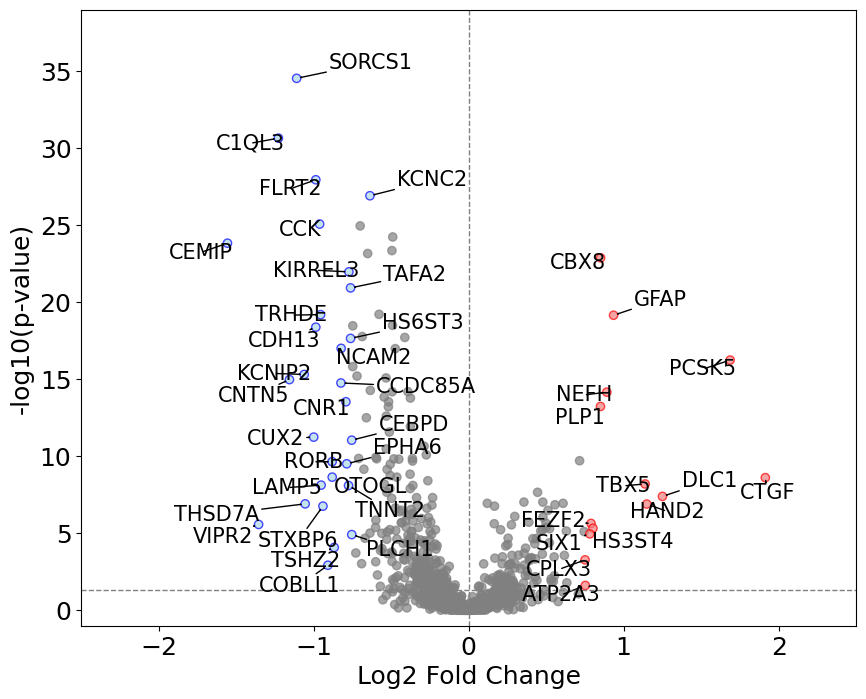

<Figure size 640x480 with 0 Axes>

In [22]:
sc.tl.rank_genes_groups(adata, groupby='Condition', groups=['>250'],       
    reference='<50',     
    method='wilcoxon'  )

s_genes=plot_volcano(adata, group='Condition', group_true_label='>250', group_false_label='<50')
plt.savefig('Figures/SF17A.pdf')

In [23]:
##################################################
#### FIGURE 7A: Bulk Differential Expression Analysis CAG >250 vs <50 (SLECTED GENES TO PLOT)
##################################################

In [24]:
deg_gn = ['HTT',
    "CBX8",
    "HAND2",
    "TBX5",
    "PARD3",
    "HOXD9",
    "CEBPD",
    "SIX1",
    "MLIP",
    "POU4F2",
    "KLK7",
    "TRHDE",
    "HOXC10",
    "ATP2A3",
    'HS3ST4',
    "PCSK5",
    'DACH1',
    'CTGF',
    'DLC1',
    'CEMIP'
]

In [25]:
def plot_volcano_deg(adata, group='Agg', 
                     log_fold_change_col='logfoldchanges', 
                     p_value_col='pvals_adj',
                     deg=deg_gn,
                     group_true_label='True', 
                     group_false_label='False'):
    
    # Extract values
    log_fold_changes = adata.uns['rank_genes_groups'][log_fold_change_col][group_true_label]
    p_values = adata.uns['rank_genes_groups'][p_value_col][group_true_label]
    gene_names = np.array(adata.uns['rank_genes_groups']['names'][group_true_label])

    # Color points based on thresholds
    colors = np.where(((log_fold_changes > 0.5) & (p_values < 0.05)),
                      'lightcoral', 'grey')
    colors = np.where(((log_fold_changes < -0.5) & (p_values < 0.05)) | (-np.log10(p_values) > 23),
                      'lightblue', colors)

    edge_colors = np.where(((log_fold_changes > 0.5) & (p_values < 0.05)) ,
                           'red', 'grey')
    edge_colors = np.where(((log_fold_changes < -0.5) & (p_values < 0.05)) | (-np.log10(p_values) > 23),
                           'blue', edge_colors)
    
    # Plot
    plt.figure(figsize=(10, 8))
    plt.scatter(log_fold_changes, -np.log10(p_values), c=colors, edgecolor=edge_colors, alpha=0.7)
    
    # Annotate only DEGs in your provided list
    annotations = []
    for gene in gene_names:
        if gene in deg:  # only label if in DEG list
            i = np.where(gene_names == gene)[0][0]
            text = plt.text(log_fold_changes[i], -np.log10(p_values)[i], gene, 
                            fontsize=18, color='black')
            annotations.append(text)

    adjust_text(annotations, arrowprops=dict(arrowstyle="->", color='black'))

    # Aesthetic elements
    plt.axhline(y=-np.log10(0.05), color='grey', linestyle='--', linewidth=1)
    plt.axvline(x=0, color='grey', linestyle='--', linewidth=1)

    plt.xlabel('Log2 Fold Change', fontsize=20)
    plt.ylabel('-log10(p-value)', fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlim(-2.5, 2.5)
    plt.ylim(-1, 39)
    plt.tight_layout()
    plt.show()

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


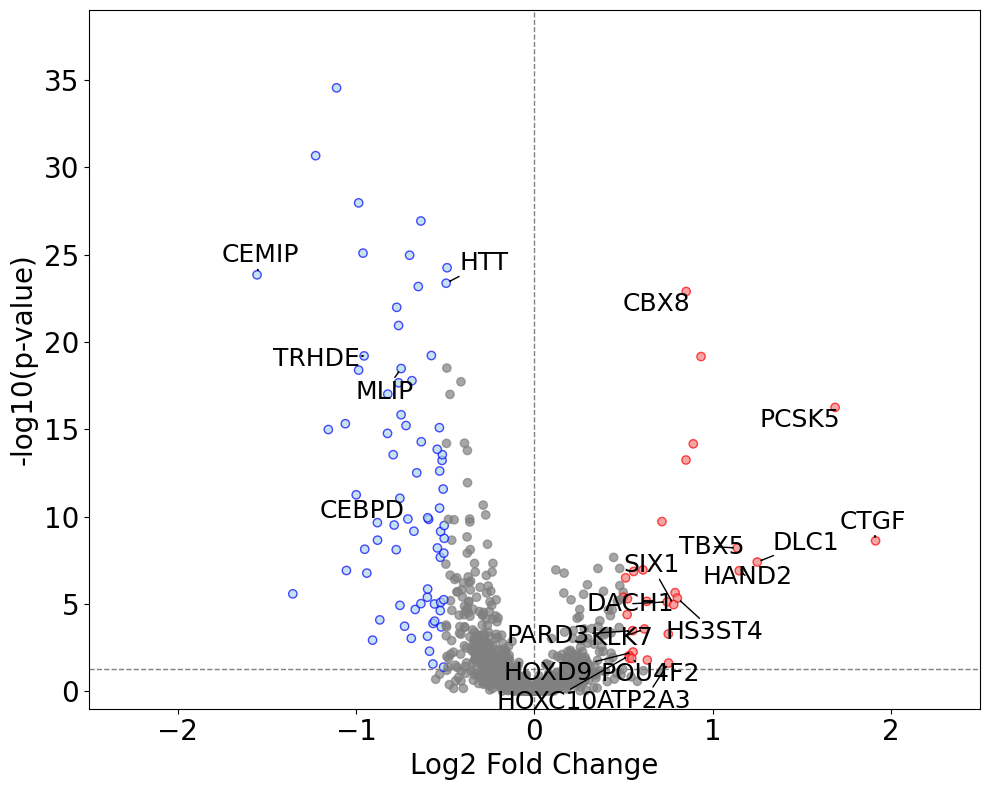

In [26]:
sc.tl.rank_genes_groups(adata, groupby='Condition', groups=['>250'],       
    reference='<50',     
    method='wilcoxon'  )

plot_volcano_deg(adata, group='Condition', deg=deg_gn, group_true_label='>250', group_false_label='<50')

In [27]:
##################################################
#### FIGURE 7B: Mean trajectories of bulk Differential Expression Analysis CAG >250 vs <50 
##################################################

In [28]:
upatient=adata.obs['patient'].unique()
upatient

['H1', 'H2', 'H4', 'H3', 'H5']
Categories (5, object): ['H1', 'H2', 'H3', 'H4', 'H5']

In [29]:
plot_dfs = {}

bins = [0, 50, 150, 250, 350, 450, np.inf]
bin_labels = ['<50', '50-150', '150-250', '250-350', '350-450', '>450']

In [30]:
for gene in s_genes:
    results = []
    ign = list(good_genes).index(gene)
    adata.obs['expr'] = adata.obsm['X_raw'][:,ign]
    
    for pt in upatient:
        # Subset data for that patient
        data_df = adata.obs[['CAG_mut','expr', 'patient']].copy()
        data_df = data_df[data_df['patient'] == pt].copy()
    
        # Clean up
        data_df['CAG_mut'] = pd.to_numeric(data_df['CAG_mut'], errors='coerce')
        data_df['expr'] = pd.to_numeric(data_df['expr'], errors='coerce')  # make sure numeric
        data_df = data_df.dropna(subset=['CAG_mut', 'expr'])
    
        # Assign bins
        data_df['CAG_bin'] = pd.cut(data_df['CAG_mut'], bins=bins, labels=bin_labels, right=True)
    
        # Compute mean nHTT per bin
        mean_per_bin = data_df.groupby('CAG_bin')['expr'].mean()
    
        # Store with patient info
        for bin_label in bin_labels:
            results.append({
                'patient': pt,
                'CAG_bin': bin_label,
                'mean_expr': mean_per_bin.get(bin_label, np.nan)  # NaN if no cells in that bin
            })
    
    plot_dfs[gene] = pd.DataFrame(results)
    print(plot_dfs[gene].head())

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55353/1298957030.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_per_bin = data_df.groupby('CAG_bin')['expr'].mean()
/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55353/1298957030.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_per_bin = data_df.groupby('CAG_bin')['expr'].mean()
/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55353/1298957030.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behav

  patient  CAG_bin  mean_expr
0      H1      <50   2.467340
1      H1   50-150   2.754156
2      H1  150-250   4.500000
3      H1  250-350   7.777778
4      H1  350-450   6.000000
  patient  CAG_bin  mean_expr
0      H1      <50  44.973278
1      H1   50-150  45.860016
2      H1  150-250  51.068966
3      H1  250-350  68.500000
4      H1  350-450  63.454544
  patient  CAG_bin  mean_expr
0      H1      <50   1.378266
1      H1   50-150   1.431321
2      H1  150-250   3.189655
3      H1  250-350   8.111111
4      H1  350-450   8.636364
  patient  CAG_bin  mean_expr
0      H1      <50  15.454275
1      H1   50-150  21.360455
2      H1  150-250  22.034483
3      H1  250-350  68.666664
4      H1  350-450  21.363636
  patient  CAG_bin  mean_expr
0      H1      <50   8.926960
1      H1   50-150  10.587051
2      H1  150-250  12.017241
3      H1  250-350  22.055555
4      H1  350-450  22.000000
  patient  CAG_bin  mean_expr
0      H1      <50   0.779691
1      H1   50-150   0.912511
2      H1 

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55353/1298957030.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_per_bin = data_df.groupby('CAG_bin')['expr'].mean()
/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55353/1298957030.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_per_bin = data_df.groupby('CAG_bin')['expr'].mean()
/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55353/1298957030.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behav

In [31]:
# Combine all gene DataFrames into one, adding a 'gene' column
combined_df = pd.concat(
    [df.assign(gene=gene) for gene, df in plot_dfs.items()],
    ignore_index=True
)

In [32]:
df_logfc = combined_df.copy()
pseudocount = 1e-4

baseline_expr = combined_df[combined_df['CAG_bin'] == '<50'].copy()
baseline_expr = baseline_expr.set_index(['patient', 'gene'])['mean_expr'] + pseudocount

df_logfc['baseline_expr'] = df_logfc.set_index(['patient', 'gene']).index.map(baseline_expr.to_dict())

df_logfc['log2FC'] = np.log2((df_logfc['mean_expr'] + pseudocount) / df_logfc['baseline_expr'])

# Optional: check result
print(df_logfc)


     patient  CAG_bin  mean_expr    gene  baseline_expr    log2FC
0         H1      <50   2.467340    CBX8       2.467440  0.000000
1         H1   50-150   2.754156    CBX8       2.467440  0.158648
2         H1  150-250   4.500000    CBX8       2.467440  0.866942
3         H1  250-350   7.777778    CBX8       2.467440  1.656362
4         H1  350-450   6.000000    CBX8       2.467440  1.281972
...      ...      ...        ...     ...            ...       ...
1285      H5   50-150  11.119970  SORCS1      10.277786  0.113636
1286      H5  150-250   9.905661  SORCS1      10.277786 -0.053190
1287      H5  250-350   7.129032  SORCS1      10.277786 -0.527731
1288      H5  350-450   8.000000  SORCS1      10.277786 -0.361440
1289      H5     >450   6.217391  SORCS1      10.277786 -0.725125

[1290 rows x 6 columns]


/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55353/1186284283.py:2: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df_logfc['CAG_bin']):


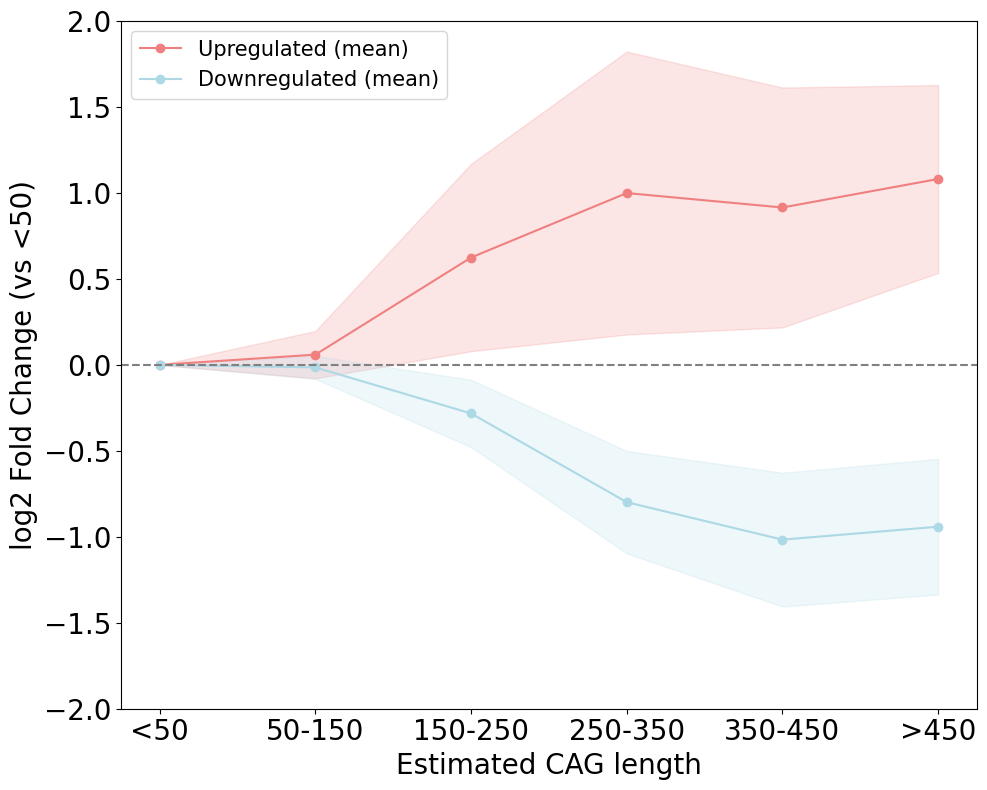

In [33]:
# 1) Ensure CAG_bin order
if pd.api.types.is_categorical_dtype(df_logfc['CAG_bin']):
    bin_order = list(df_logfc['CAG_bin'].cat.categories)
else:
    bin_order = list(df_logfc['CAG_bin'].unique())

# 2) Aggregate mean log2FC per gene per bin
df_mean = df_logfc.groupby(['gene', 'CAG_bin'])['log2FC'].mean().reset_index()

# 3) Pivot: genes x bins
pivot = df_mean.pivot(index='gene', columns='CAG_bin', values='log2FC').reindex(columns=bin_order)

# 4) Split genes into upregulated (last bin > 0) and downregulated (last bin < 0)
last_vals = pivot.ffill(axis=1).iloc[:, -1]   # last non-NaN per row
up_genes = pivot.loc[last_vals > 0]
down_genes = pivot.loc[last_vals < 0]

# 5) Compute mean and std per bin for each group
up_mean = up_genes.mean(skipna=True)
up_std = up_genes.std(skipna=True)

down_mean = down_genes.mean(skipna=True)
down_std = down_genes.std(skipna=True)

x = np.arange(len(bin_order))
plt.figure(figsize=(10, 8))

# --- Upregulated group (blue) ---
plt.plot(x, up_mean, color='lightcoral', marker='o', label='Upregulated (mean)')
plt.fill_between(x, up_mean - up_std, up_mean + up_std, color='lightcoral', alpha=0.2)

# --- Downregulated group (red) ---
plt.plot(x, down_mean, color='lightblue', marker='o', label='Downregulated (mean)')
plt.fill_between(x, down_mean - down_std, down_mean + down_std, color='lightblue', alpha=0.2)

# 6) Tidy up
plt.axhline(0, linestyle='--', color='gray')
plt.xticks(x, bin_order, size=20)
plt.yticks(size=20)
plt.xlabel('Estimated CAG length', size=20)
plt.ylabel('log2 Fold Change (vs <50)', size=20)
plt.title('', size=22)
plt.ylim(-2,2)
plt.legend(loc="upper left",fontsize=15)
plt.tight_layout()
plt.savefig('Figures/F7B.pdf')

plt.show()


In [34]:
##################################################
#### SUPPLEMENTARY FIGURE 17B-C: Bulk Differential Expression Analysis CAG >250 vs <50 (SLECTED GENE PATHWAYS TO PLOT)
##################################################

In [35]:
dna_repair = ['FAN1', 'HMGB1', 'LIG1',  'LIG4', 'PMS1','PMS2','MSH2','MSH3','MSH4','MSH5', 'MSH6', 'MLH1','MLH3','POLD1']


TF_DBP = [
    "ATOH8", "BARX1",  'CBX5', 'CBX3','CBX8', "CEBPD",  'CUX2', 'DLX1','EYA4', 'FEZF2', 'FOXP2', "GLI2", "GSX1", "HAND1", "HAND2",
    "HIF3A", "HOXA10", "HOXA11", "HOXA13", "HOXA4", "HOXA5", "HOXA7",
    "HOXB9", "HOXC10", "HOXC6", "HOXD10", "HOXD8", "HOXD9",
    'MNX1',"KLF15",'KRBOX4', "OTP", "PAX2", "PITX1", "POU4F2", 'RORB',"SIX1", "TBX5",'TOX', 'TSHZ2','TFEB',  'POU3F2', 
]


In [36]:
def plot_volcano_pathway(
        adata, group='Agg', 
        log_fold_change_col='logfoldchanges', 
        p_value_col='pvals',
        deg=deg_gn,
        group_true_label='True', 
        group_false_label='False', c='violet', ec='purple'):

    # Extract values
    logFC = adata.uns['rank_genes_groups'][log_fold_change_col][group_true_label] 
    pvals = adata.uns['rank_genes_groups'][p_value_col][group_true_label]
    genes = np.array(adata.uns['rank_genes_groups']['names'][group_true_label])

    neglogp = -np.log10(pvals)

    # Background scatter
    plt.figure(figsize=(10, 8))
    plt.scatter(logFC, neglogp, c='grey', alpha=0.7)

    # Annotate selected genes if significant
    annotations = []
    for gene in deg:
        idx = np.where(genes == gene)[0]
        if len(idx) == 0:
            continue
        idx = idx[0]

        # check significance
        is_sig = (pvals[idx] < 0.05)

        # highlight selected gene
        plt.scatter(logFC[idx], neglogp[idx],
                    color=c,edgecolor=ec, s=70)

        # annotate only if significant
        if is_sig:
            txt = plt.text(logFC[idx], neglogp[idx], gene,
                           fontsize=18, color='black', weight='bold')
            annotations.append(txt)

    adjust_text(annotations, arrowprops=dict(arrowstyle="->", color='black'))

    # aesthetics
    plt.axhline(y=-np.log10(0.05), color='grey', linestyle='--', linewidth=1)
    plt.axvline(x=0, color='grey', linestyle='--', linewidth=1)

    plt.xlabel('Log2 Fold Change', fontsize=20)
    plt.ylabel('-log10(p-value)', fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlim(-2.5, 2.5)

    plt.tight_layout()
    plt.show()

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


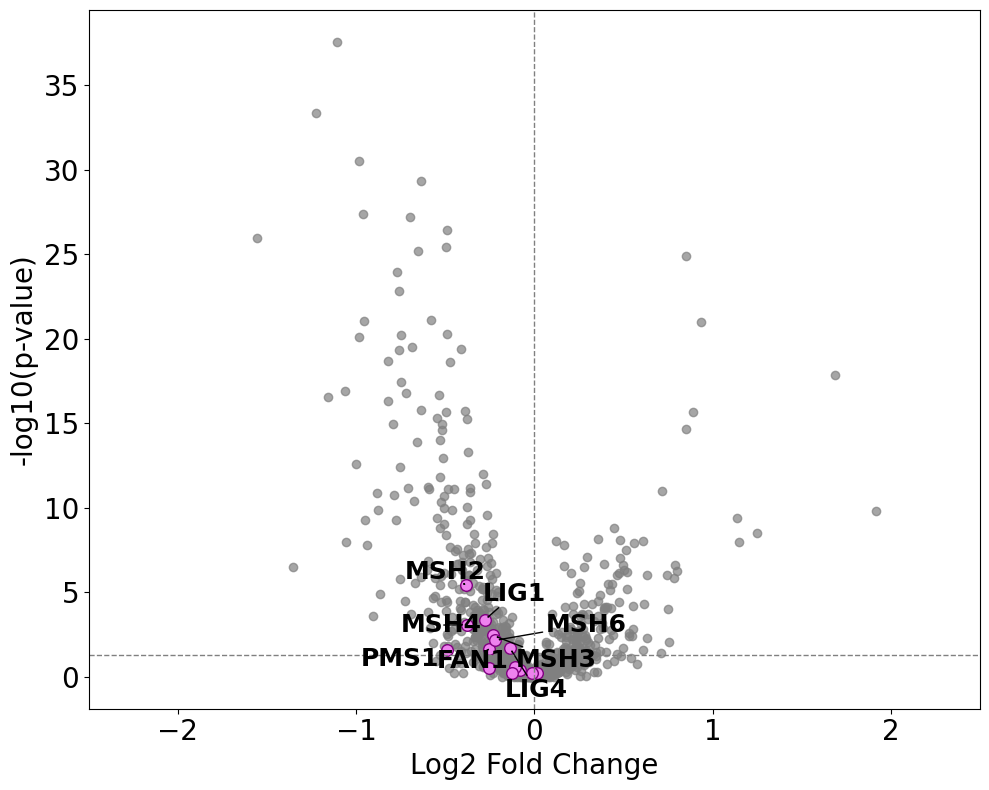

In [37]:
sc.tl.rank_genes_groups(adata, groupby='Condition', groups=['>250'],       
    reference='<50',     
    method='wilcoxon'  )

# Plot volcano for all cells
plot_volcano_pathway(adata, group='Condition', deg=dna_repair, group_true_label='>250', group_false_label='<50')


/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


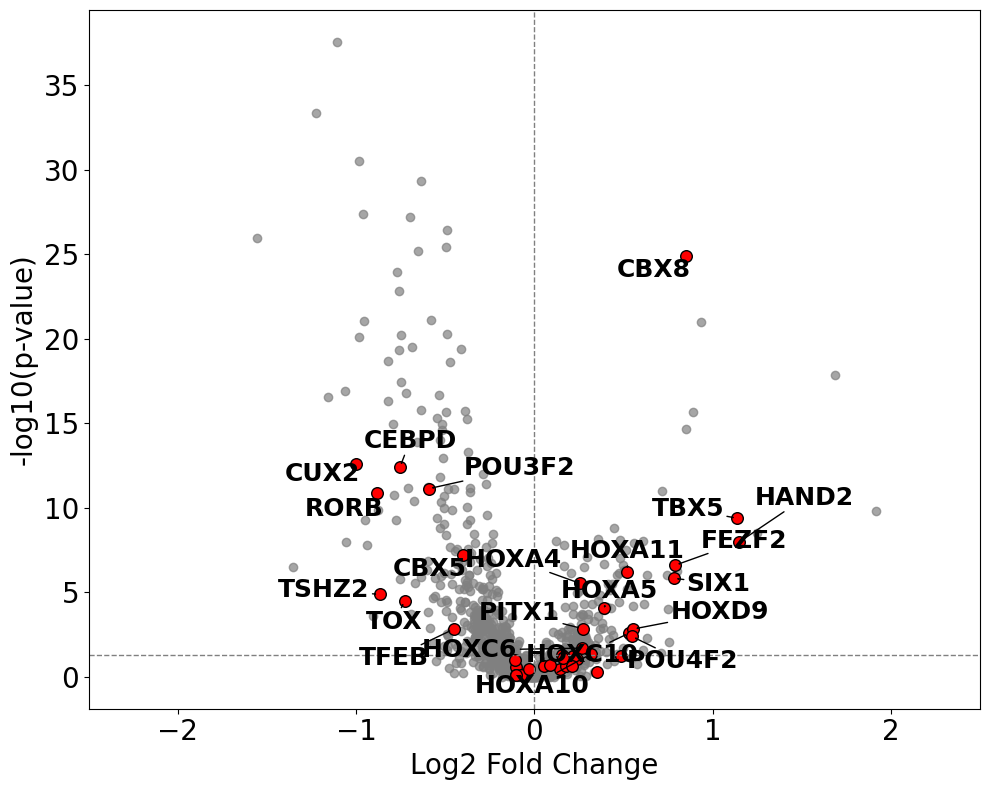

In [38]:
sc.tl.rank_genes_groups(adata, groupby='Condition', groups=['>250'],       
    reference='<50',     
    method='wilcoxon'  )

plot_volcano_pathway(adata, group='Condition', c='red', ec='black', deg=TF_DBP, group_true_label='>250', group_false_label='<50')

In [39]:
##################################################
#### SUPPLEMENTARY FIGURE 17D-E: Mean trajectories of bulk Differential Expression Analysis CAG >250 vs <50 (SELECTED GENES TO PLOT)
##################################################

In [40]:
plot_dfs = {}

In [41]:
for gene in deg_gn:
    results = []
    ign = list(good_genes).index(gene)
    adata.obs['expr'] = adata.obsm['X_raw'][:,ign]
    
    for pt in upatient:
        # Subset data for that patient
        data_df = adata.obs[['CAG_mut','expr', 'patient']].copy()
        data_df = data_df[data_df['patient'] == pt].copy()
    
        # Clean up
        data_df['CAG_mut'] = pd.to_numeric(data_df['CAG_mut'], errors='coerce')
        data_df['expr'] = pd.to_numeric(data_df['expr'], errors='coerce')  # make sure numeric
        data_df = data_df.dropna(subset=['CAG_mut', 'expr'])
    
        # Assign bins
        data_df['CAG_bin'] = pd.cut(data_df['CAG_mut'], bins=bins, labels=bin_labels, right=True)
    
        # Compute mean nHTT per bin
        mean_per_bin = data_df.groupby('CAG_bin')['expr'].mean()
    
        # Store with patient info
        for bin_label in bin_labels:
            results.append({
                'patient': pt,
                'CAG_bin': bin_label,
                'mean_expr': mean_per_bin.get(bin_label, np.nan)  # NaN if no cells in that bin
            })
    
    plot_dfs[gene] = pd.DataFrame(results)
    print(plot_dfs[gene].head())

  patient  CAG_bin  mean_expr
0      H1      <50  21.938242
1      H1   50-150  22.773403
2      H1  150-250  22.465517
3      H1  250-350  20.888889
4      H1  350-450  18.090910
  patient  CAG_bin  mean_expr
0      H1      <50   2.467340
1      H1   50-150   2.754156
2      H1  150-250   4.500000
3      H1  250-350   7.777778
4      H1  350-450   6.000000
  patient  CAG_bin  mean_expr
0      H1      <50   1.285036
1      H1   50-150   1.384077
2      H1  150-250   2.327586
3      H1  250-350   4.944445
4      H1  350-450   3.272727
  patient  CAG_bin  mean_expr
0      H1      <50   0.480404
1      H1   50-150   0.485564
2      H1  150-250   0.810345
3      H1  250-350   4.111111
4      H1  350-450   1.090909
  patient  CAG_bin  mean_expr
0      H1      <50   1.134798
1      H1   50-150   1.056868
2      H1  150-250   1.844828
3      H1  250-350   2.333333
4      H1  350-450   2.818182
  patient  CAG_bin  mean_expr
0      H1      <50   0.818290
1      H1   50-150   0.804025
2      H1 

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55353/1817289144.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_per_bin = data_df.groupby('CAG_bin')['expr'].mean()
/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55353/1817289144.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_per_bin = data_df.groupby('CAG_bin')['expr'].mean()
/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55353/1817289144.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behav

In [42]:
# Combine all gene DataFrames into one, adding a 'gene' column
combined_df = pd.concat(
    [df.assign(gene=gene) for gene, df in plot_dfs.items()],
    ignore_index=True
)

In [43]:
df_logfc = combined_df.copy()
pseudocount = 1e-4

baseline_expr = combined_df[combined_df['CAG_bin'] == '<50'].copy()
baseline_expr = baseline_expr.set_index(['patient', 'gene'])['mean_expr'] + pseudocount

df_logfc['baseline_expr'] = df_logfc.set_index(['patient', 'gene']).index.map(baseline_expr.to_dict())

df_logfc['log2FC'] = np.log2((df_logfc['mean_expr'] + pseudocount) / df_logfc['baseline_expr'])

# Optional: check result
print(df_logfc)


    patient  CAG_bin  mean_expr   gene  baseline_expr    log2FC
0        H1      <50  21.938242    HTT      21.938341  0.000000
1        H1   50-150  22.773403    HTT      21.938341  0.053902
2        H1  150-250  22.465517    HTT      21.938341  0.034264
3        H1  250-350  20.888889    HTT      21.938341 -0.070712
4        H1  350-450  18.090910    HTT      21.938341 -0.278182
..      ...      ...        ...    ...            ...       ...
595      H5   50-150   1.641551  CEMIP       1.905059 -0.214688
596      H5  150-250   1.031447  CEMIP       1.905059 -0.885026
597      H5  250-350   0.354839  CEMIP       1.905059 -2.424194
598      H5  350-450   0.600000  CEMIP       1.905059 -1.666561
599      H5     >450   0.521739  CEMIP       1.905059 -1.868158

[600 rows x 6 columns]


/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55353/18364920.py:1: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df_logfc['CAG_bin']):


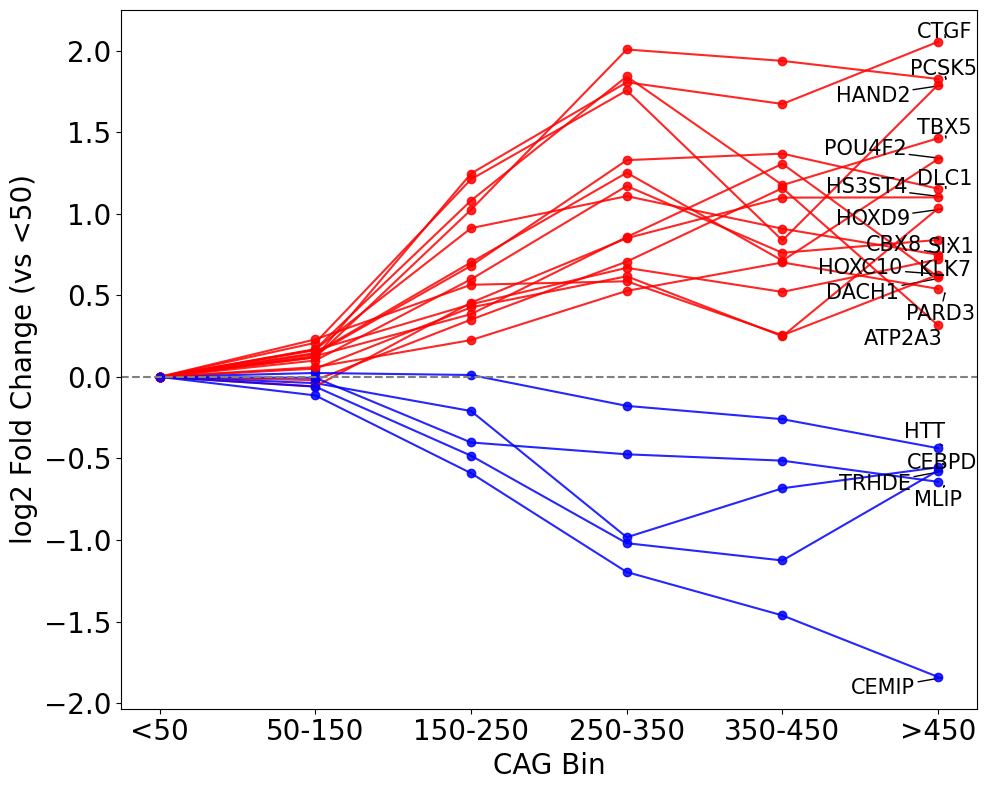

In [44]:
if pd.api.types.is_categorical_dtype(df_logfc['CAG_bin']):
    bin_order = list(df_logfc['CAG_bin'].cat.categories)
else:
    bin_order = list(df_logfc['CAG_bin'].unique())

df_mean = df_logfc.groupby(['gene', 'CAG_bin'])['log2FC'].mean().reset_index()

pivot = df_mean.pivot(index='gene', columns='CAG_bin', values='log2FC').reindex(columns=bin_order)

plt.figure(figsize=(10, 8))
texts = []
offset = 0  
x = np.arange(len(bin_order))

for gene, row in pivot.iterrows():
    if row.isna().all():
        continue

    y = row.values.astype(float)
    try:
        last_val = row.dropna().iloc[-1]
    except IndexError:
        continue

    line_color = 'red' if last_val > 0 else 'blue'

    plt.plot(x, y, marker='o', color=line_color, alpha=0.85, linewidth=1.5)

    if not np.isnan(last_val):
        txt = plt.text(
            len(bin_order) - 1 + 0.05,
            last_val + offset,
            gene,
            fontsize=15,
            va='center',
            ha='right',
            color='black'  # <-- always black now
        )
        texts.append(txt)

plt.axhline(0, linestyle='--', color='gray')
plt.xticks(x, bin_order, size=20)
plt.yticks( size=20)
plt.xlabel('CAG Bin', size=20)
plt.ylabel('log2 Fold Change (vs <50)', size=20)
plt.title('', size=14)
plt.tight_layout()

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black'))
plt.savefig('Figures/SF17D.pdf')

plt.show()


/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55353/3018393100.py:2: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df_logfc['CAG_bin']):


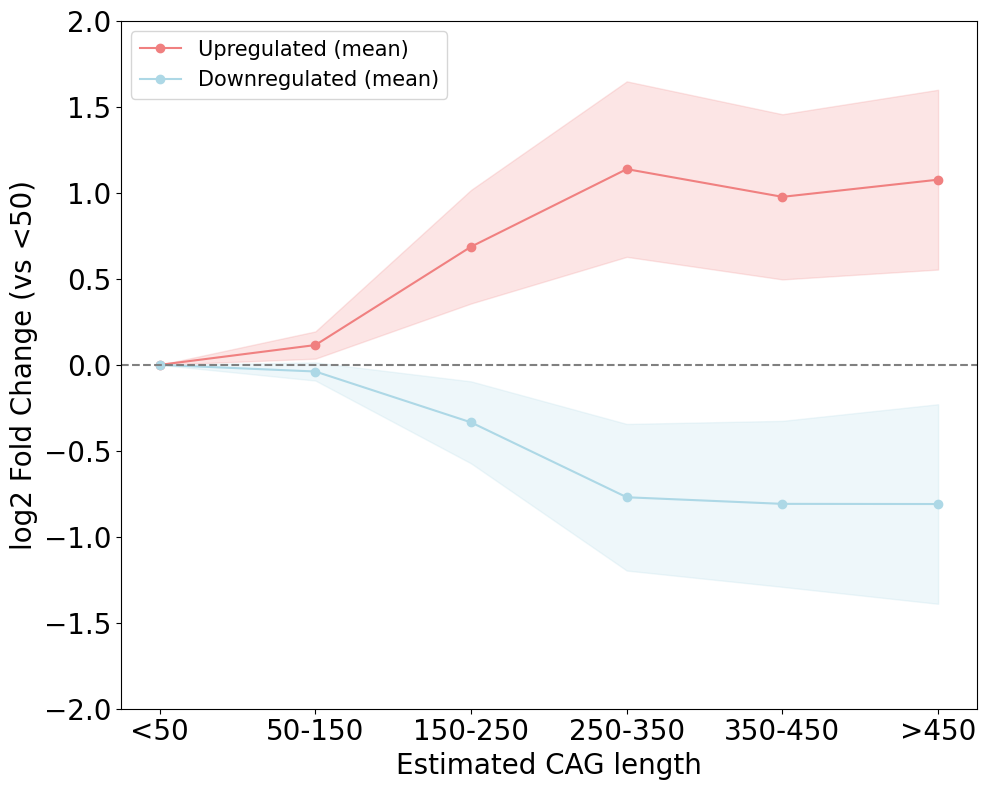

In [45]:
# 1) Ensure CAG_bin order
if pd.api.types.is_categorical_dtype(df_logfc['CAG_bin']):
    bin_order = list(df_logfc['CAG_bin'].cat.categories)
else:
    bin_order = list(df_logfc['CAG_bin'].unique())

# 2) Aggregate mean log2FC per gene per bin
df_mean = df_logfc.groupby(['gene', 'CAG_bin'])['log2FC'].mean().reset_index()

# 3) Pivot: genes x bins
pivot = df_mean.pivot(index='gene', columns='CAG_bin', values='log2FC').reindex(columns=bin_order)

# 4) Split genes into upregulated (last bin > 0) and downregulated (last bin < 0)
last_vals = pivot.ffill(axis=1).iloc[:, -1]   # last non-NaN per row
up_genes = pivot.loc[last_vals > 0]
down_genes = pivot.loc[last_vals < 0]

# 5) Compute mean and std per bin for each group
up_mean = up_genes.mean(skipna=True)
up_std = up_genes.std(skipna=True)

down_mean = down_genes.mean(skipna=True)
down_std = down_genes.std(skipna=True)

x = np.arange(len(bin_order))
plt.figure(figsize=(10, 8))

# --- Upregulated group (blue) ---
plt.plot(x, up_mean, color='lightcoral', marker='o', label='Upregulated (mean)')
plt.fill_between(x, up_mean - up_std, up_mean + up_std, color='lightcoral', alpha=0.2)

# --- Downregulated group (red) ---
plt.plot(x, down_mean, color='lightblue', marker='o', label='Downregulated (mean)')
plt.fill_between(x, down_mean - down_std, down_mean + down_std, color='lightblue', alpha=0.2)

# 6) Tidy up
plt.axhline(0, linestyle='--', color='gray')
plt.xticks(x, bin_order, size=20)
plt.yticks(size=20)
plt.xlabel('Estimated CAG length', size=20)
plt.ylabel('log2 Fold Change (vs <50)', size=20)
plt.title('', size=22)
plt.ylim(-2,2)
plt.legend(loc="upper left",fontsize=15)
plt.tight_layout()
plt.savefig('Figures/SF17E.pdf')

plt.show()


In [46]:
##################################################
####FIGURE 7E: Differential Expression Analysis with Inclusion in paired populations
##################################################

In [47]:
def plot_volcano(adata, group='Agg', log_fold_change_col='logfoldchanges',xlimn=2, xlimp=3,ylim=85, foldc=0.5, labpval=15, p_value_col='pvals',
                 csv='Exc N', group_true_label='True', group_false_label='False',color='magenta'):
    log_fold_changes = adata.uns['rank_genes_groups'][log_fold_change_col][group_true_label]
    p_values = adata.uns['rank_genes_groups'][p_value_col][group_true_label]
    gene_names = adata.uns['rank_genes_groups']['names'][group_true_label]
    
    significant = (np.abs(log_fold_changes) >= 0.5) & (p_values < 0.05)
    colors = np.where(significant, color, 'grey')
    
    plt.figure(figsize=(10, 8))
    
    plt.scatter(log_fold_changes, -np.log10(p_values), c=colors, alpha=0.7)
    
    significant_genes_indices = np.where(((np.abs(log_fold_changes) >= foldc) & (p_values < 0.05))|( -np.log10(p_values) > labpval))[0]
    annotations = []
    for i in significant_genes_indices:
        text = plt.text(log_fold_changes[i], -np.log10(p_values)[i], gene_names[i], fontsize=16, color='black')
        annotations.append(text)
    
    plt.axhline(y=-np.log10(0.05), color='grey', linestyle='--', linewidth=1)
    plt.axvline(x=0, color='grey', linestyle='--', linewidth=1)

    plt.xlabel('Log2 Fold Change', fontsize=18)
    plt.ylabel('-log10(p-value)', fontsize=18)
    plt.title(f'{group} True vs False for {csv}', fontsize=30)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.xlim(-xlimn,+xlimp)
    plt.ylim(0,+ylim)

    red_patch = plt.Line2D([0], [0], marker='o', color='b', markerfacecolor='red', markersize=10, label='Significant')
    blue_patch = plt.Line2D([0], [0], marker='o', color='b', markerfacecolor='blue', markersize=10, label='Non-significant')

    adjust_text(annotations, arrowprops=dict(arrowstyle="->", color='black'))

    significant_genes = pd.DataFrame({
        'gene': gene_names[significant],
        'log2_fold_change': log_fold_changes[significant],
        'p_value': p_values[significant]
    })
    os.makedirs("DEG", exist_ok=True)
    significant_genes.to_csv(f'DEG/DEG_{group}_{csv}_{patient}.csv', index=False)
    print(f"Significant genes for patient {patient} saved to 'DEG_{group}_{csv}.csv''")
    
    plt.show()
    return significant_genes

In [48]:
HD_Exc = HD_adata[HD_adata.obs['cluster_general']=='Excitatory Neurons'].copy()

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Significant genes for patient  saved to 'DEG_Agg_Exc_N_Neighbour.csv''


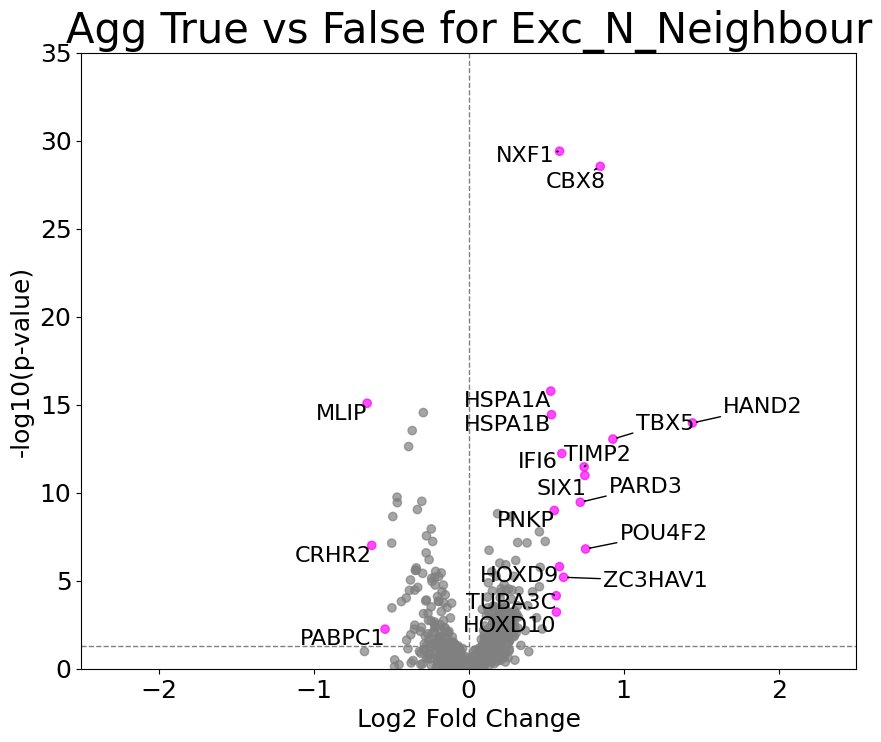

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Significant genes for patient  saved to 'DEG_Agg_L2.IT-72-.csv''


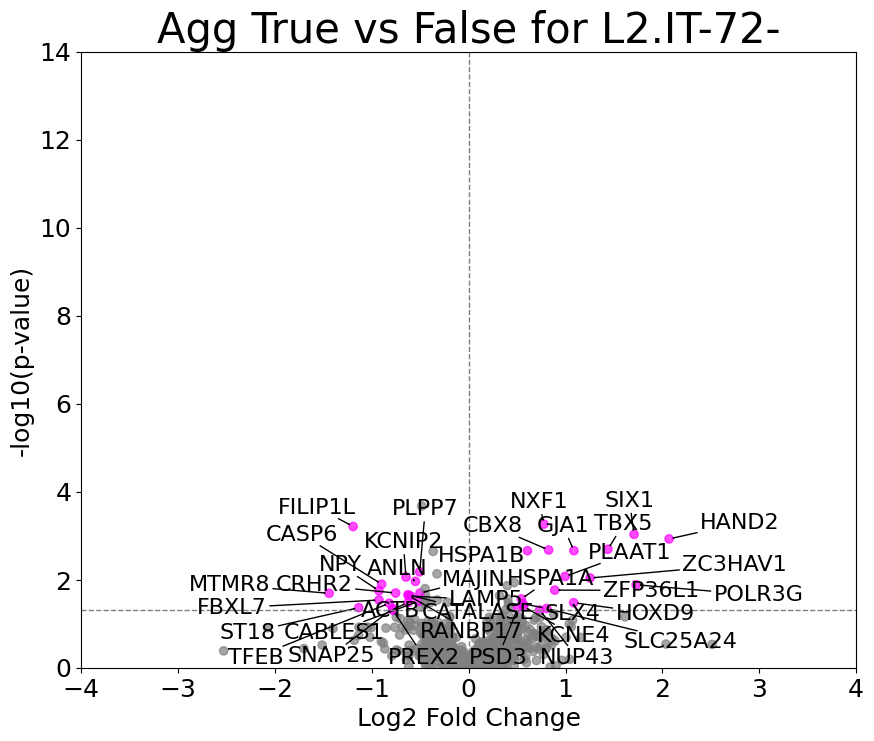

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Significant genes for patient  saved to 'DEG_Agg_L3.IT-294-.csv''


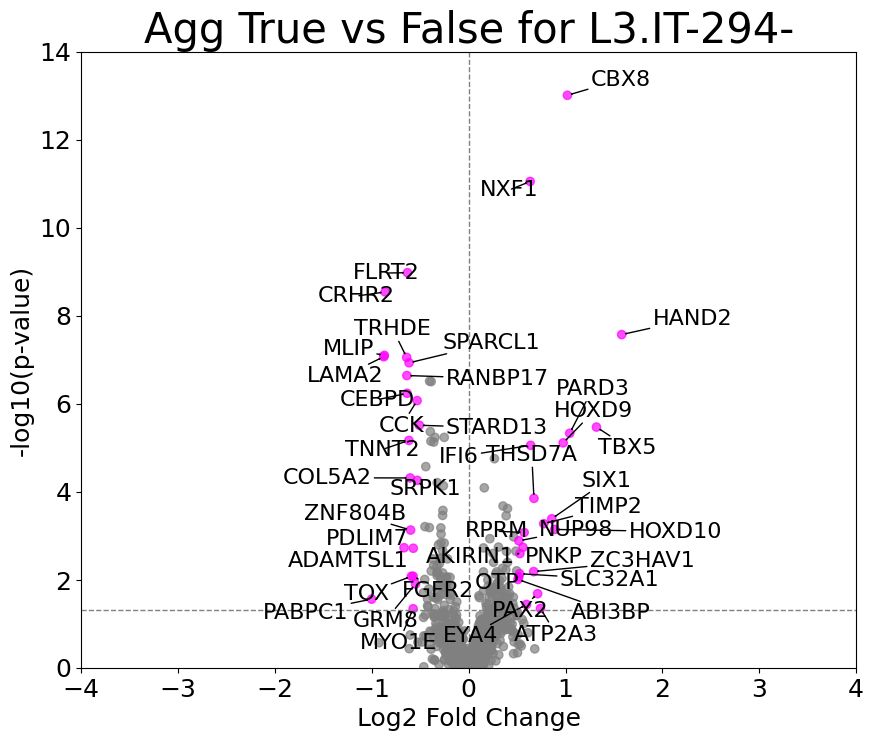

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Significant genes for patient  saved to 'DEG_Agg_L4.IT-52-.csv''


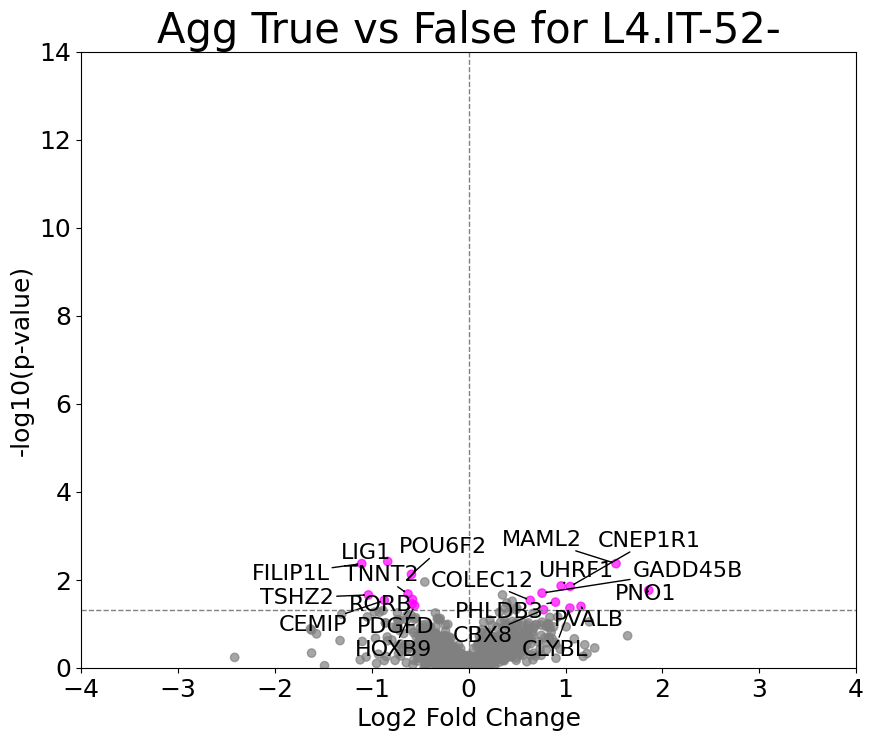

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Significant genes for patient  saved to 'DEG_Agg_L5.IT-240-.csv''


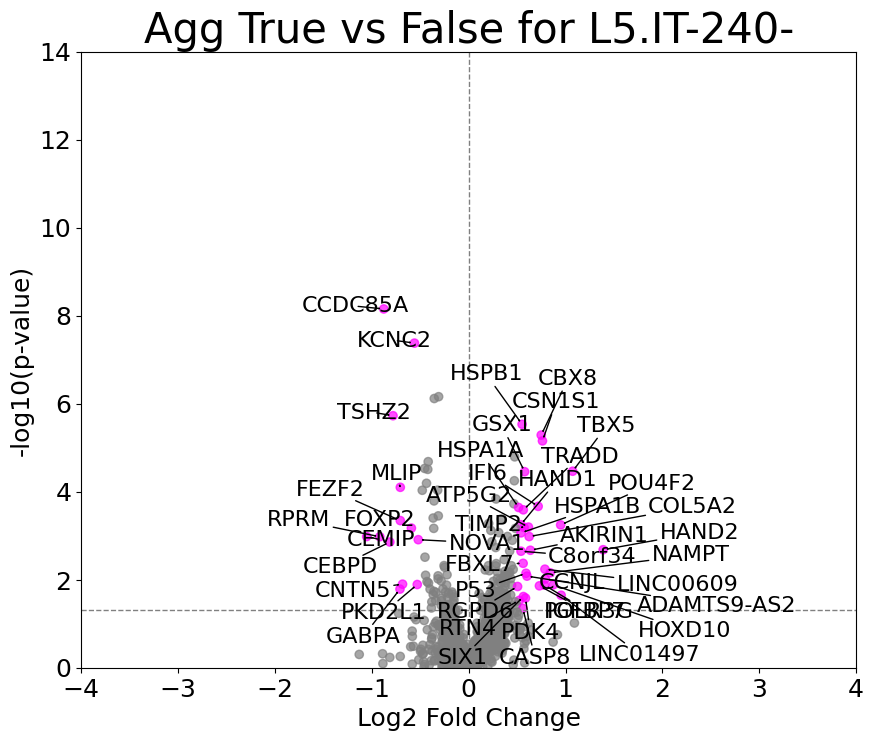

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Significant genes for patient  saved to 'DEG_Agg_L6.CT-35-.csv''


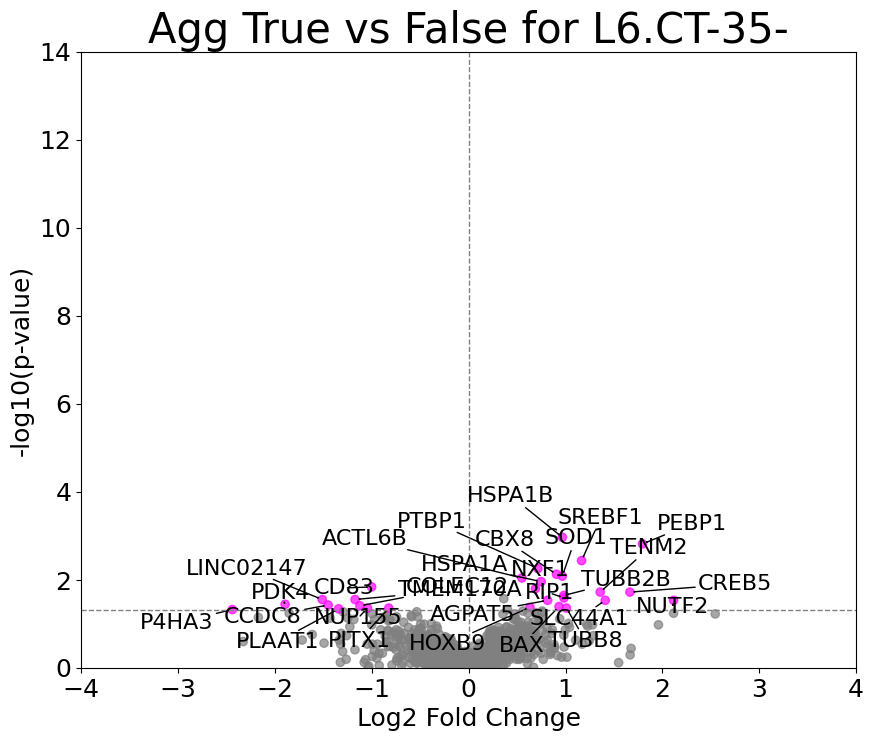

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Significant genes for patient  saved to 'DEG_Agg_L6.Car3-15-.csv''


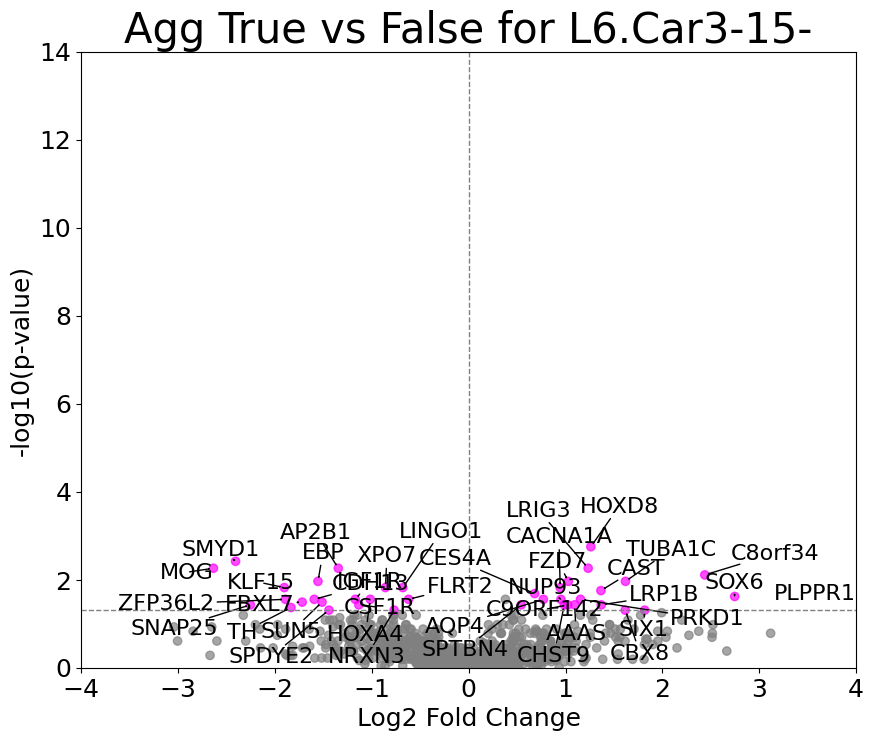

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Significant genes for patient  saved to 'DEG_Agg_L6.IT-214-.csv''


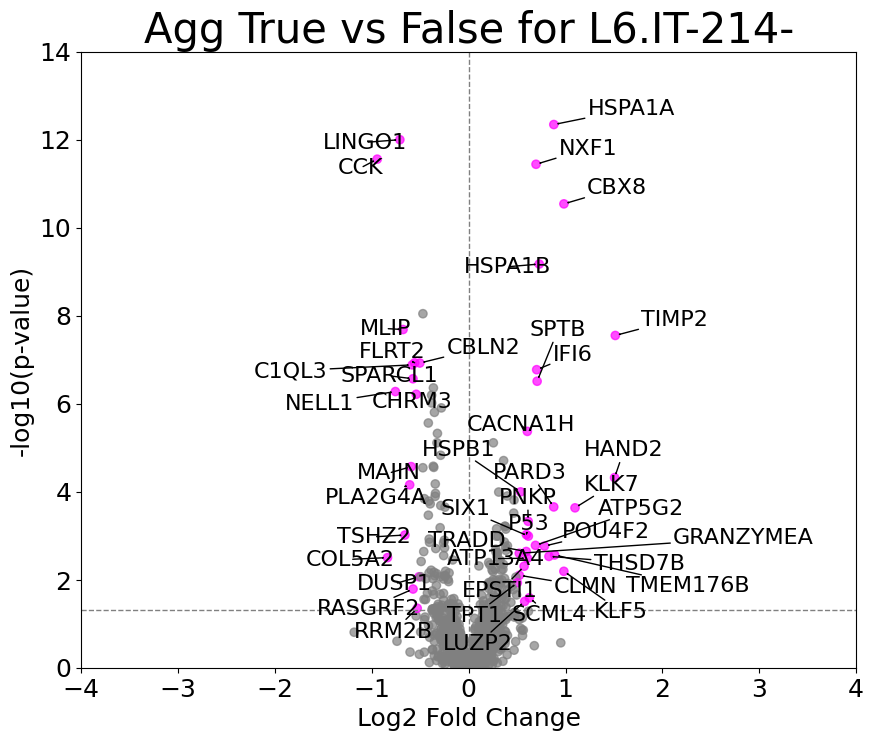

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Significant genes for patient  saved to 'DEG_Agg_L6b-95-.csv''


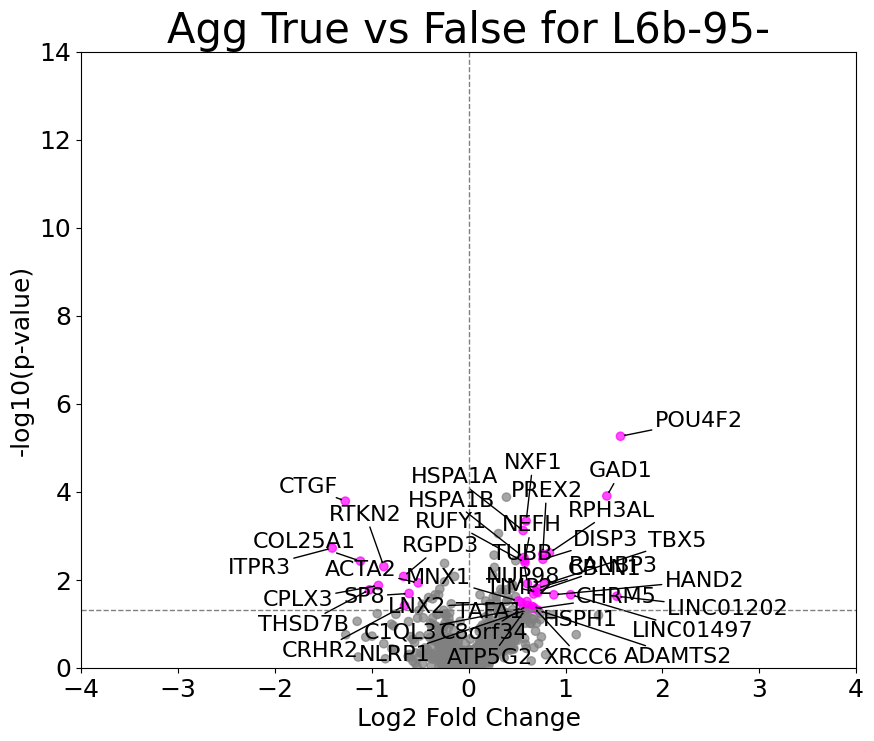

In [49]:
from scipy.spatial import KDTree
plt.rcdefaults()

HD_Exc.obs['Category'] = 'none'
HD_Exc.obs['Agg'] = HD_Exc.obs['Agg'].fillna(False).astype('bool')

kind = 'Agg'
color = '#23ff0a'

for patient in HD_Exc.obs.patient.cat.categories:
    for names in HD_Exc.obs.cluster_names.cat.categories:   
        same = HD_Exc.obs.loc[(HD_Exc.obs.patient==patient) & (HD_Exc.obs.cluster_names==names) & ( HD_Exc.obs[kind])]
        diff = HD_Exc.obs.loc[(HD_Exc.obs.patient==patient) & (HD_Exc.obs.cluster_names==names) & ((HD_Exc.obs[kind] == 0) | (HD_Exc.obs[kind].isna()))]
            
        spatial_xy = HD_Exc.obsm['X_spatial'][:, :2]
        diff_idx = HD_Exc.obs.index.get_indexer(diff.index)
        same_idx = HD_Exc.obs.index.get_indexer(same.index)
        tree = KDTree(spatial_xy[diff_idx])
        dists, indices = tree.query(spatial_xy[same_idx], k=2)
        HD_Exc.obs.loc[same.index, 'Category'] = kind+'+'
        HD_Exc.obs.loc[diff.iloc[indices[:,0]].index,'Category'] = kind+'-'

HD_Exc.obs['Category'] = HD_Exc.obs['Category'].astype('category')

patient=''

if True:
    subset_adata = HD_Exc[(HD_Exc.obs['Category']!='none')]
    sc.tl.rank_genes_groups(subset_adata, group='Agg', groupby='Category', method='wilcoxon', use_raw=False)
    s_agg_exc = plot_volcano(subset_adata,csv='Exc_N_Neighbour',ylim=35,xlimn=2.5,xlimp=2.5, group_true_label=kind+'+', group_false_label=[kind+'-'])

for names in HD_Exc.obs.cluster_names.cat.categories:
    subset_adata_ = HD_Exc[(HD_Exc.obs.cluster_names == names) & (HD_Exc.obs['Category']!='none')]
    if len(subset_adata_) > 10:
        sc.tl.rank_genes_groups(subset_adata_, group='Agg', groupby='Category', method='wilcoxon', use_raw=False)
        plot_volcano(subset_adata_,csv=names+'-'+str(len(subset_adata_))+'-',xlimn=4,xlimp=4, ylim=14, group_true_label=kind+'+', group_false_label=[kind+'-'])

In [50]:
##################################################
#### SUPPLEMENTARY FIGURE 18B: Differential Expression Analysis with inclusions paired populations per cell type
##################################################

In [51]:
logfc_agg_ng, pval_agg_ng = siglogfc(subset_adata, condition='Agg+')

In [52]:
HD_Exc.obs['Category'].value_counts()

Category
none    15158
Agg+      529
Agg-      494
Name: count, dtype: int64

In [53]:
s_agg_exc

,gene,log2_fold_change,p_value
0,NXF1,0.586613,3.942693e-30
1,CBX8,0.849188,2.856962e-29
2,HSPA1A,0.529673,1.687379e-16
3,HSPA1B,0.534524,3.670059e-15
4,HAND2,1.444062,1.082888e-14
5,TBX5,0.930751,8.986939e-14
6,IFI6,0.601137,5.922305e-13
7,TIMP2,0.744841,3.402666e-12
8,SIX1,0.749803,1.036890e-11
9,PARD3,0.720361,3.483205e-10


In [54]:
genes_of_interest = s_agg_exc['gene'].values

lfc_mat = pd.DataFrame(index=genes_of_interest)
p_mat = pd.DataFrame(index=genes_of_interest)

for cl in HD_Exc.obs.cluster_names.cat.categories:

    subset = HD_Exc[
        (HD_Exc.obs['cluster_names'] == cl) &
        (HD_Exc.obs['Category'] != 'none')
    ]

    if len(subset) < 10:
        continue

    sc.tl.rank_genes_groups(
        subset,
        groupby='Category',
        groups=['Agg+'],
        reference='Agg-',
        method='wilcoxon',
        use_raw=False
    )

    names = subset.uns['rank_genes_groups']['names']['Agg+']
    lfc = subset.uns['rank_genes_groups']['logfoldchanges']['Agg+'] / np.log(2)
    pvals = subset.uns['rank_genes_groups']['pvals']['Agg+']

    tmp_lfc = pd.Series(lfc, index=names)
    tmp_p = pd.Series(pvals, index=names)

    lfc_mat[cl] = tmp_lfc.reindex(genes_of_interest)
    p_mat[cl] = tmp_p.reindex(genes_of_interest)

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a futur

In [55]:
global_lfc = (
    s_agg_exc
    .set_index('gene')['log2_fold_change']
)

lfc_mat.insert(
    0,
    'Global_Exc',
    global_lfc.reindex(lfc_mat.index)
)

In [56]:
global_p = (
    s_agg_exc
    .set_index('gene')['p_value']
)

p_mat.insert(
    0,
    'Global_Exc',
    global_p.reindex(p_mat.index)
)

In [57]:
lfc_mat = lfc_mat.sort_values('Global_Exc', ascending=False)
p_mat = p_mat.loc[lfc_mat.index]

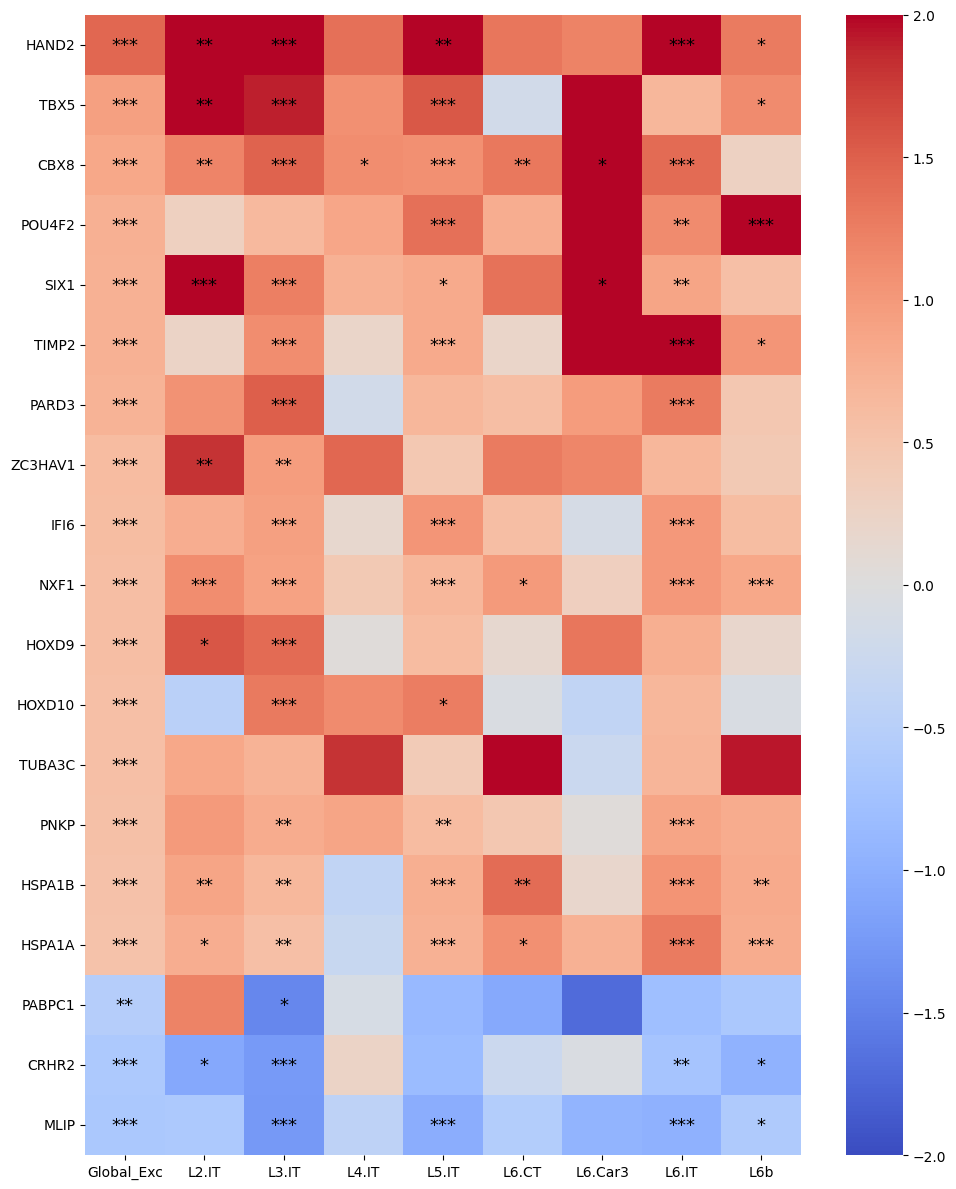

In [58]:
lfc_sig = lfc_mat.copy()

plt.figure(figsize=(10, 12))

ax = sns.heatmap(
    lfc_sig,
    cmap='coolwarm',
    center=0,
    vmin=-2,
    vmax=2
)

for i in range(lfc_mat.shape[0]):      # genes
    for j in range(lfc_mat.shape[1]):  # clusters

        p = p_mat.iloc[i, j]

        if pd.isna(p):
            continue

        if p < 0.001:
            star = '***'
        elif p < 0.01:
            star = '**'
        elif p < 0.05:
            star = '*'
        else:
            continue

        ax.text(
            j + 0.5,
            i + 0.5,
            star,
            ha='center',
            va='center',
            color='black',
            fontsize=13
        )

plt.tight_layout()
plt.show()

In [59]:
##################################################
#### FIGURE 7D: Differential Expression Analysis CAG >250 vs <50 paired populations
##################################################

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Significant genes for patient  saved to 'DEG_Expansion_Exc_N_Neighbour.csv''


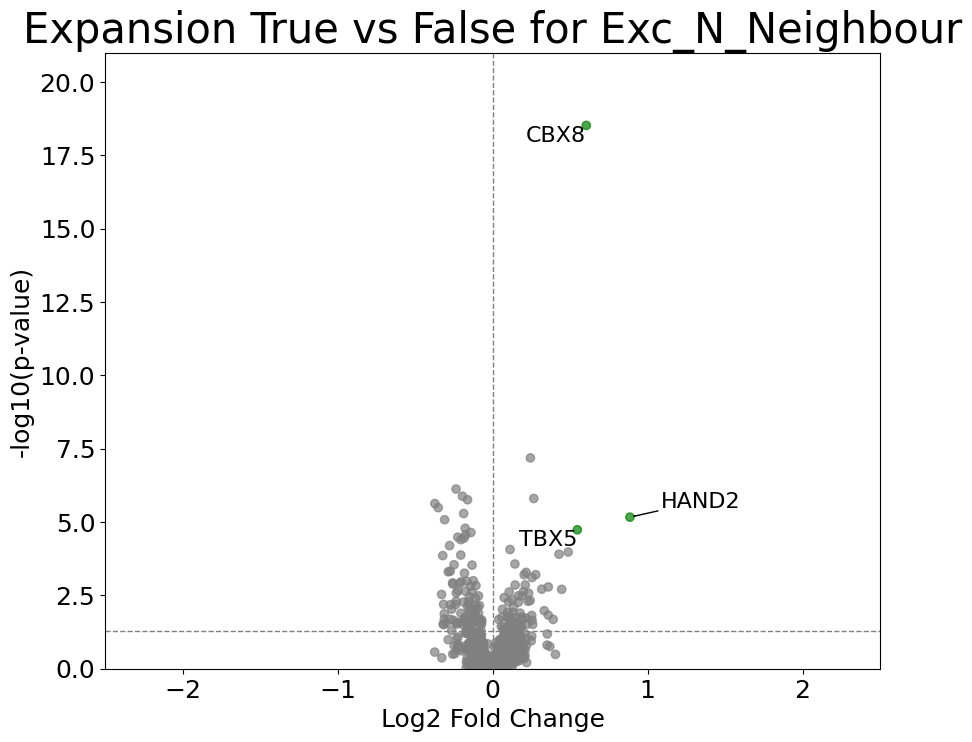

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Significant genes for patient  saved to 'DEG_Expansion_250_L2.IT-88-.csv''


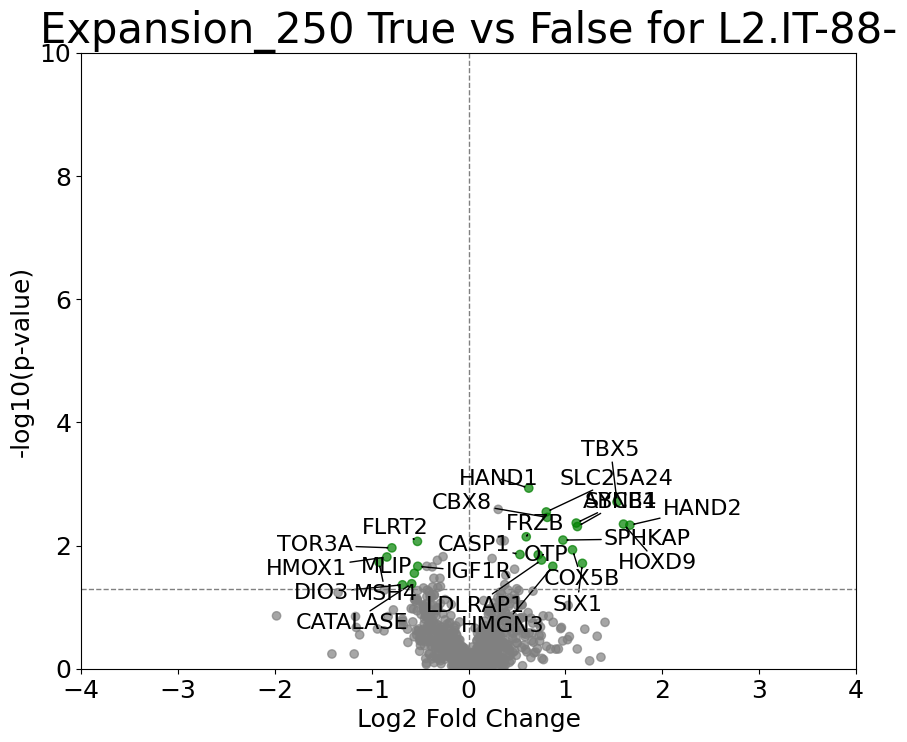

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Significant genes for patient  saved to 'DEG_Expansion_250_L3.IT-411-.csv''


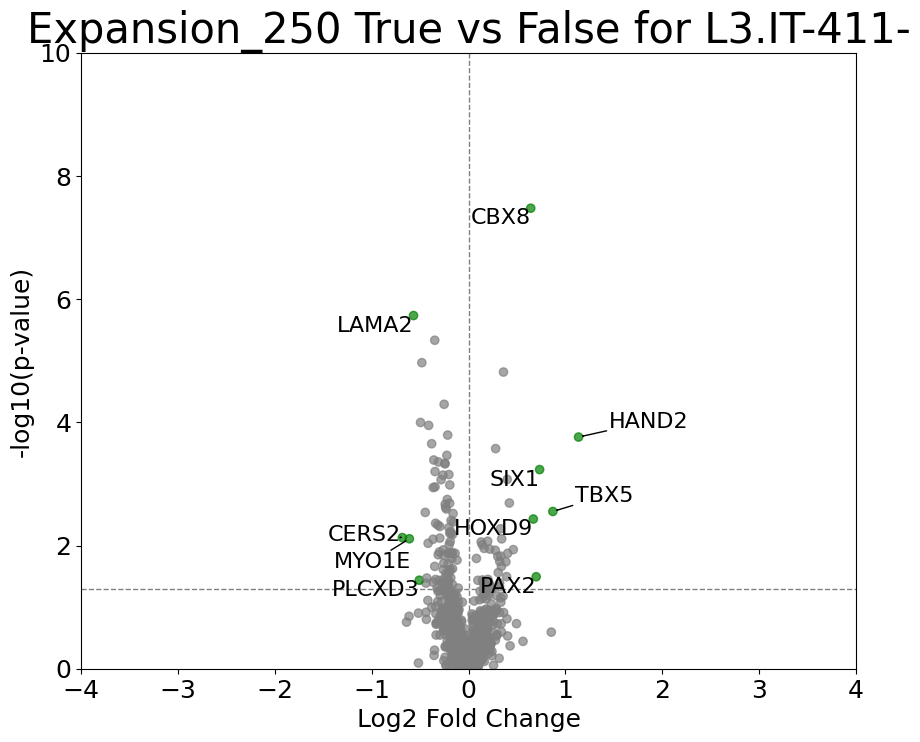

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Significant genes for patient  saved to 'DEG_Expansion_250_L4.IT-60-.csv''


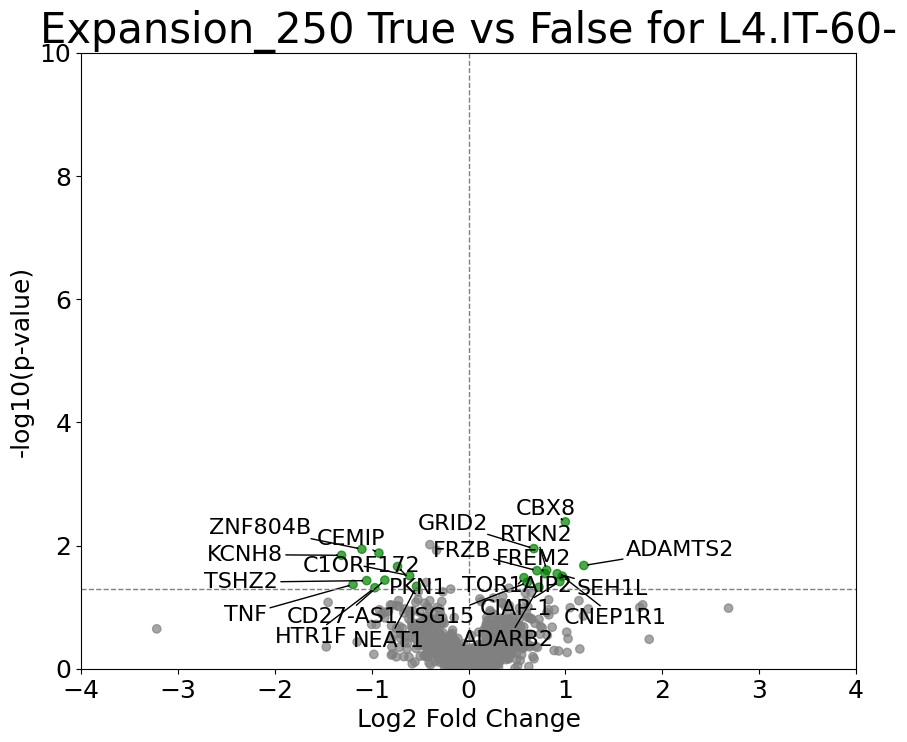

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Significant genes for patient  saved to 'DEG_Expansion_250_L5.6.NP-39-.csv''


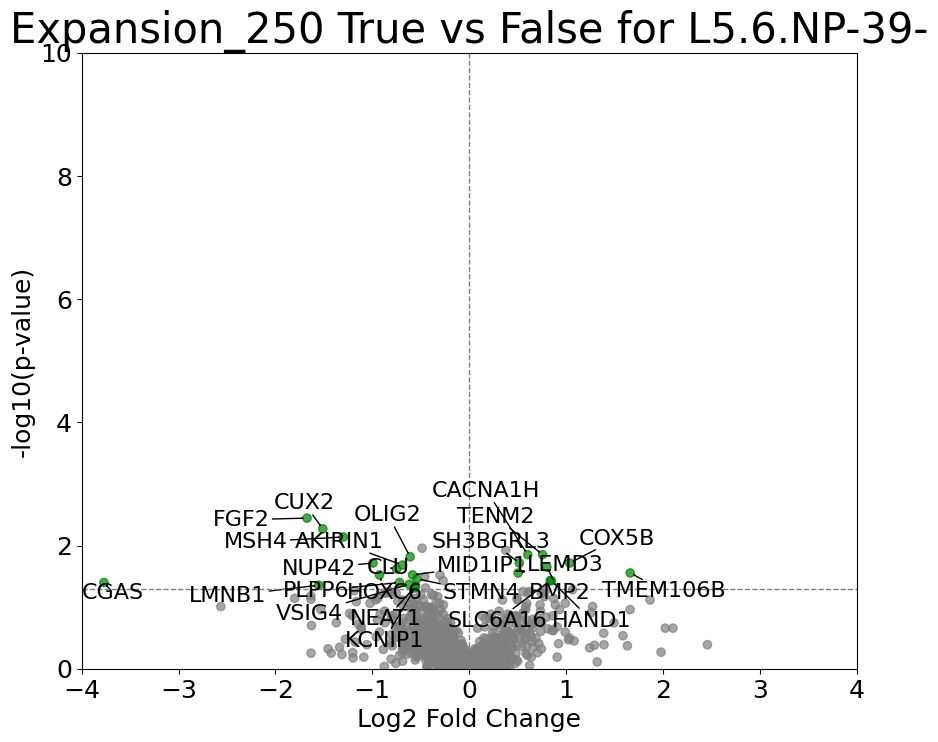

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Significant genes for patient  saved to 'DEG_Expansion_250_L5.ET-35-.csv''


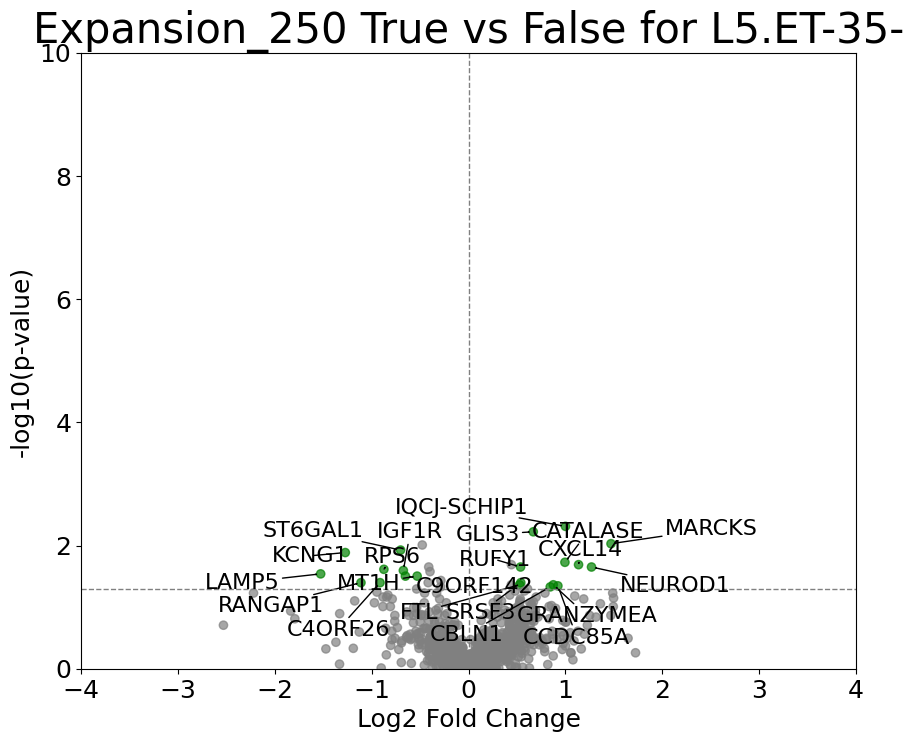

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Significant genes for patient  saved to 'DEG_Expansion_250_L5.IT-183-.csv''


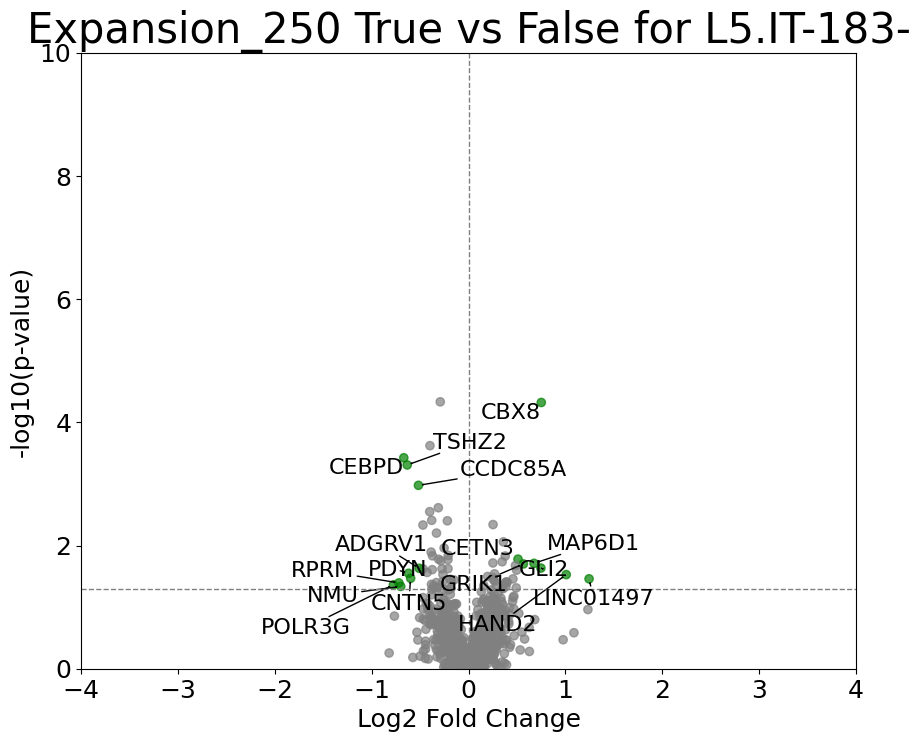

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Significant genes for patient  saved to 'DEG_Expansion_250_L6.CT-34-.csv''


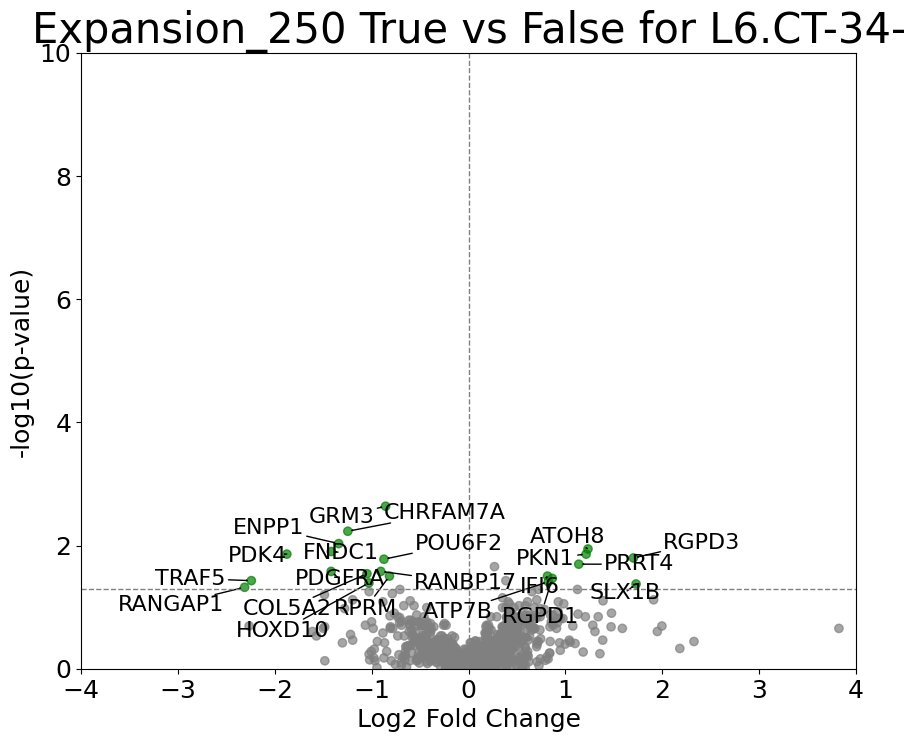

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Significant genes for patient  saved to 'DEG_Expansion_250_L6.Car3-70-.csv''


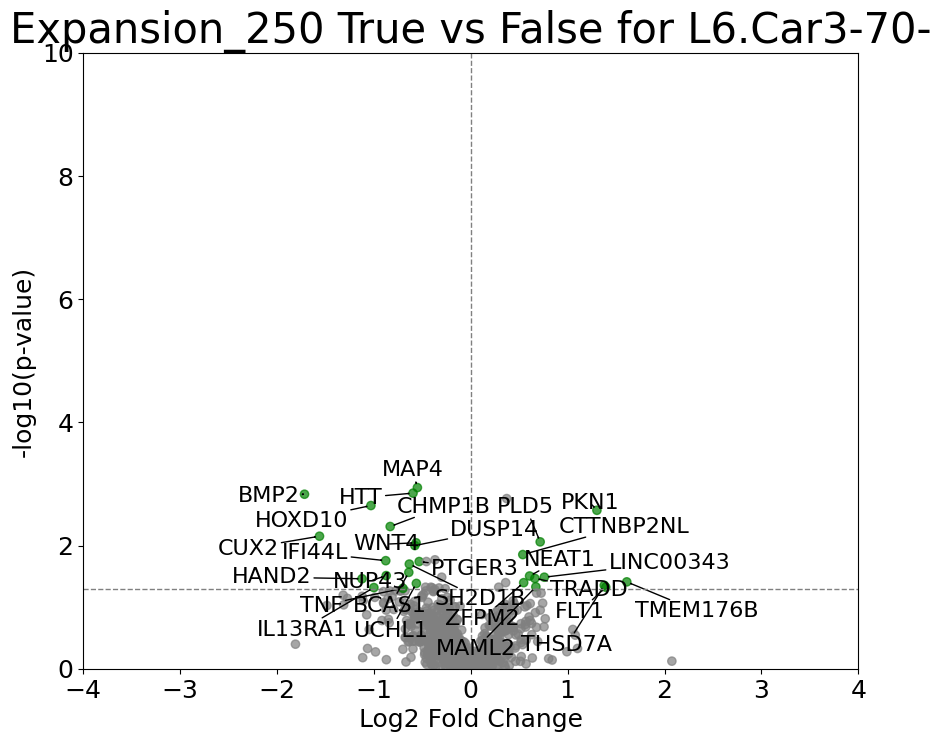

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Significant genes for patient  saved to 'DEG_Expansion_250_L6.IT-133-.csv''


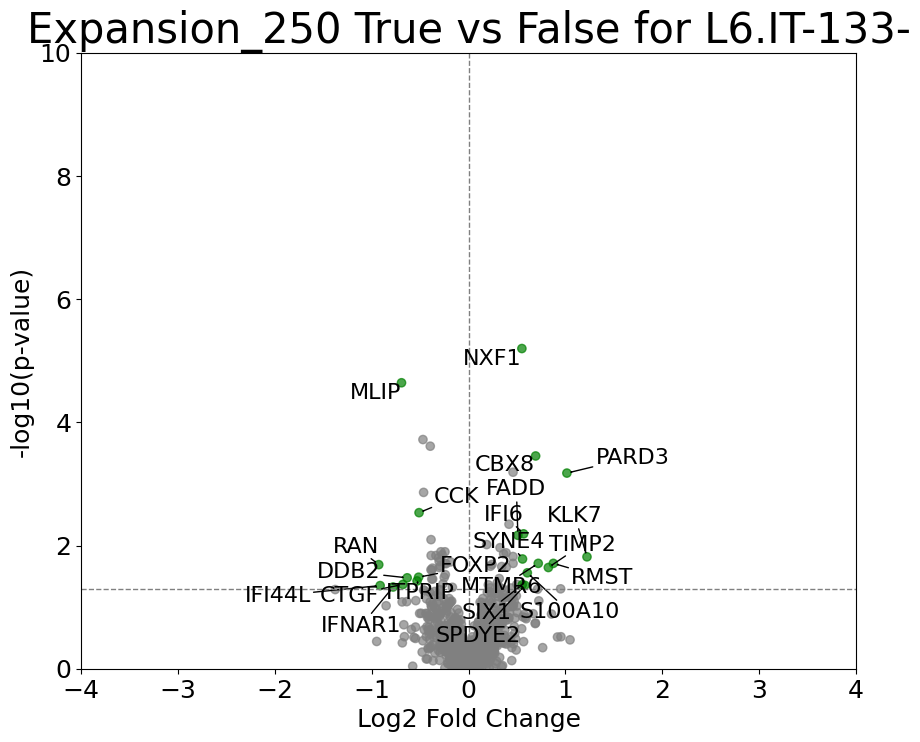

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Significant genes for patient  saved to 'DEG_Expansion_250_L6b-170-.csv''


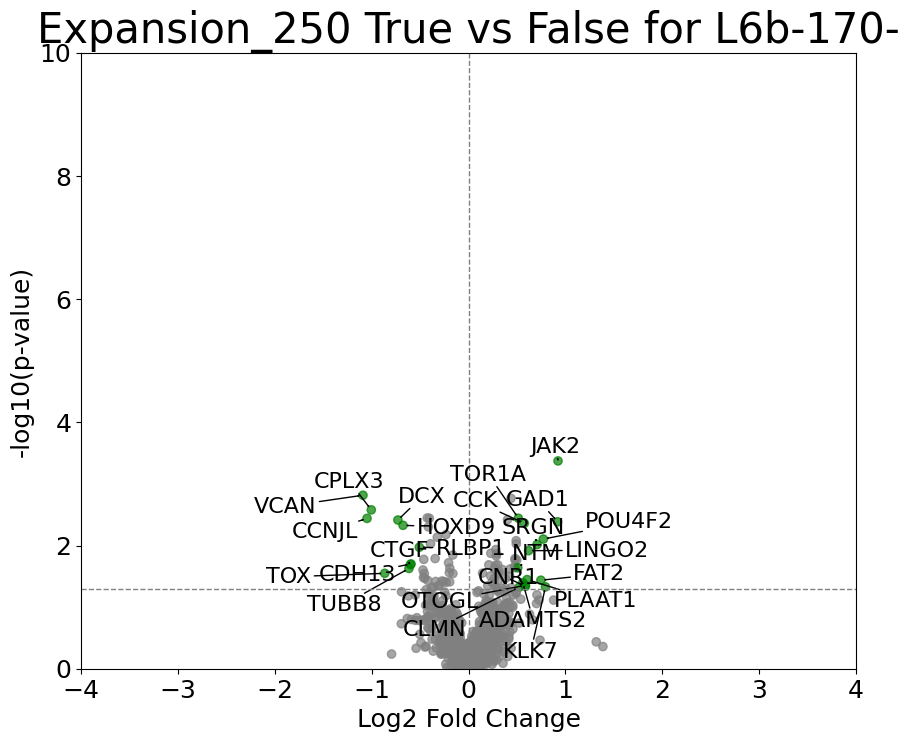

In [60]:
plt.rcdefaults()

HD_Exc_5.obs['Category'] = 'none'
HD_Exc_5.obs['Expansion'] = HD_Exc_5.obs['Expansion'].astype(bool)

kind = 'Expansion_250'
color = '#23ff0a'

for patient in HD_Exc_5.obs.patient.cat.categories:
    for names in HD_Exc_5.obs.cluster_names.cat.categories:   
        # NOT SAME
        same = HD_Exc_5.obs.loc[(HD_Exc_5.obs.patient==patient) & (HD_Exc_5.obs.cluster_names==names) & ( HD_Exc_5.obs[kind])]
        diff = HD_Exc_5.obs.loc[(HD_Exc_5.obs.patient==patient) & (HD_Exc_5.obs.cluster_names==names) & ((HD_Exc_5.obs[kind] == 0) | (HD_Exc.obs[kind].isna()))]
        
        spatial_xy = HD_Exc_5.obsm['X_spatial'][:, :2]
        diff_idx = HD_Exc_5.obs.index.get_indexer(diff.index)
        same_idx = HD_Exc_5.obs.index.get_indexer(same.index)
        tree = KDTree(spatial_xy[diff_idx])
        dists, indices = tree.query(spatial_xy[same_idx], k=2)
        HD_Exc_5.obs.loc[same.index, 'Category'] = kind+'+'
        HD_Exc_5.obs.loc[diff.iloc[indices[:,0]].index,'Category'] = kind+'-'

HD_Exc_5.obs['Category'] = HD_Exc_5.obs['Category'].astype('category')
patient=''

if True:
    subset_adata = HD_Exc_5[(HD_Exc_5.obs['Category']!='none')]
    sc.tl.rank_genes_groups(subset_adata, groupby='Category', method='wilcoxon', use_raw=False)
    s_exp_exc = plot_volcano(subset_adata,group='Expansion',csv='Exc_N_Neighbour', group_true_label=kind+'+',xlimn=2.5,xlimp=2.5, ylim=21,foldc=0.5, group_false_label=[kind+'-'], color='green')


for names in HD_Exc_5.obs.cluster_names.cat.categories:
    subset_adata_ = HD_Exc_5[(HD_Exc_5.obs.cluster_names == names) & (HD_Exc_5.obs['Category']!='none')]
    if len(subset_adata_) > 10:
        sc.tl.rank_genes_groups(subset_adata_, groupby='Category', method='wilcoxon', use_raw=False)
        plot_volcano(subset_adata_,group='Expansion_250',csv=names+'-'+str(len(subset_adata_))+'-',xlimn=4,xlimp=4, ylim=10, group_true_label=kind+'+', group_false_label=[kind+'-'],color='green')



In [61]:
##################################################
#### SUPPLEMENTARY FIGURE 18A: Differential Expression Analysis CAG >250 vs <50 paired populations per cell type
##################################################

In [62]:
logfc_cag_ng, pval_cag_ng = siglogfc(subset_adata, condition='Expansion_250+')

In [63]:
s_exp_exc

,gene,log2_fold_change,p_value
0,CBX8,0.605010,3.002545e-19
1,HAND2,0.886360,6.797453e-06
2,TBX5,0.547034,1.832018e-05


In [64]:
genes_of_interest = s_exp_exc['gene'].values

lfc_mat = pd.DataFrame(index=genes_of_interest)
p_mat = pd.DataFrame(index=genes_of_interest)

for cl in HD_Exc.obs.cluster_names.cat.categories:

    subset = HD_Exc_5[
        (HD_Exc_5.obs['cluster_names'] == cl) &
        (HD_Exc_5.obs['Category'] != 'none')
    ]

    if len(subset) < 10:
        continue

    sc.tl.rank_genes_groups(
        subset,
        groupby='Category',
        groups=['Expansion_250+'],
        reference='Expansion_250-',
        method='wilcoxon',
        use_raw=False
    )

    names = subset.uns['rank_genes_groups']['names']['Expansion_250+']
    lfc = subset.uns['rank_genes_groups']['logfoldchanges']['Expansion_250+'] / np.log(2)
    pvals = subset.uns['rank_genes_groups']['pvals']['Expansion_250+']

    tmp_lfc = pd.Series(lfc, index=names)
    tmp_p = pd.Series(pvals, index=names)

    lfc_mat[cl] = tmp_lfc.reindex(genes_of_interest)
    p_mat[cl] = tmp_p.reindex(genes_of_interest)

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a futur

In [65]:
lfc_mat

,L2.IT,L3.IT,L4.IT,L5.6.NP,L5.ET,L5.IT,L6.CT,L6.Car3,L6.IT,L6b
CBX8,1.172984,0.926262,1.441447,0.702531,0.616314,1.083602,0.484573,0.057895,0.999483,0.385544
HAND2,2.402722,1.638640,0.769779,-0.521303,-0.534568,1.455121,2.290832,-1.618907,1.371626,0.712263
TBX5,2.211787,1.255660,1.197001,0.028665,-0.226009,0.538118,0.084412,0.287183,0.602590,-0.096538


In [66]:
global_lfc = (
    s_exp_exc
    .set_index('gene')['log2_fold_change']
)

lfc_mat.insert(
    0,
    'Global_Exc',
    global_lfc.reindex(lfc_mat.index)
)

In [67]:
global_p = (
    s_exp_exc
    .set_index('gene')['p_value']
)

p_mat.insert(
    0,
    'Global_Exc',
    global_p.reindex(p_mat.index)
)

In [68]:
lfc_mat = lfc_mat.sort_values('Global_Exc', ascending=False)
p_mat = p_mat.loc[lfc_mat.index]

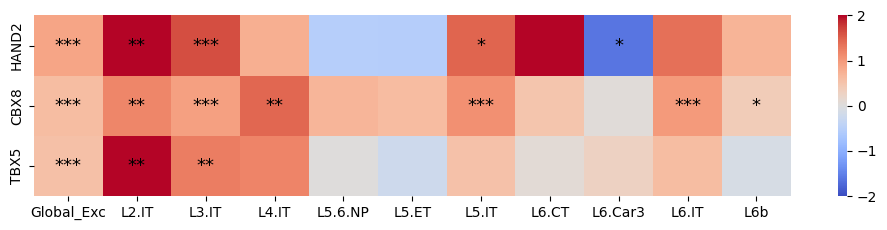

In [69]:
lfc_sig = lfc_mat.copy()

plt.figure(figsize=(10, 0.8*len(lfc_mat)))

ax = sns.heatmap(
    lfc_sig,
    cmap='coolwarm',
    center=0,
    vmin=-2,
    vmax=2
)

for i in range(lfc_mat.shape[0]):      # genes
    for j in range(lfc_mat.shape[1]):  # clusters

        p = p_mat.iloc[i, j]

        if pd.isna(p):
            continue

        if p < 0.001:
            star = '***'
        elif p < 0.01:
            star = '**'
        elif p < 0.05:
            star = '*'
        else:
            continue

        ax.text(
            j + 0.5,
            i + 0.5,
            star,
            ha='center',
            va='center',
            color='black',
            fontsize=13
        )

plt.tight_layout()
plt.show()

In [70]:
##################################################
#### FIGURE 7F: Corrrelation of Fold Changes Inclusions and CAGs
##################################################

In [71]:
from matplotlib.lines import Line2D

def classify_driving(df_fc, min_abs_fc=0.0, require_sign_agreement=True):
    """
    df_fc must contain columns: 'logFC_CAG', 'logFC_Agg' (and optionally pvals).
    min_abs_fc: minimum absolute FC (log2 units) to consider a gene 'strong' (set 0 to include all).
    Returns df with a new 'driver_category' column and count summary.
    """
    df = df_fc.copy()
    a = df['logFC_Agg']
    c = df['logFC_CAG']
    df['absA'] = a.abs()
    df['absC'] = c.abs()
    df['same_sign'] = np.sign(a) == np.sign(c)
    df['category'] = 'other'   # default
    
    # both up
    up_mask = (a > 0) & (c > 0)
    df.loc[up_mask & (df['absA'] > df['absC']) & (df['absA'] >= min_abs_fc), 'category'] = 'Agg-driven (up)'
    df.loc[up_mask & (df['absC'] > df['absA']) & (df['absC'] >= min_abs_fc), 'category'] = 'CAG-driven (up)'
    df.loc[up_mask & (df['absA'] == df['absC']) & (df['absA'] >= min_abs_fc), 'category'] = 'Equal (up)'

    # both down
    down_mask = (a < 0) & (c < 0)
    # note: for negatives, larger absolute value means more negative (stronger down)
    df.loc[down_mask & (df['absA'] > df['absC']) & (df['absA'] >= min_abs_fc), 'category'] = 'Agg-driven (down)'
    df.loc[down_mask & (df['absC'] > df['absA']) & (df['absC'] >= min_abs_fc), 'category'] = 'CAG-driven (down)'
    df.loc[down_mask & (df['absA'] == df['absC']) & (df['absA'] >= min_abs_fc), 'category'] = 'Equal (down)'

    # discordant sign (opposite directions)
    discord_mask = (np.sign(a) != np.sign(c))
    df.loc[discord_mask & (df['absA'] > df['absC']) & (df['absA'] >= min_abs_fc), 'category'] = 'Agg-dominant (discord)'
    df.loc[discord_mask & (df['absC'] > df['absA']) & (df['absC'] >= min_abs_fc), 'category'] = 'CAG-dominant (discord)'
    df.loc[discord_mask & (df['absA'] == df['absC']) & (df['absA'] >= min_abs_fc), 'category'] = 'Equal (discord)'

    # weak (both below threshold)
    df.loc[(df['absA'] < min_abs_fc) & (df['absC'] < min_abs_fc), 'category'] = 'weak'

    # summary counts
    counts = df['category'].value_counts()
    total = len(df)
    pct = (counts / total * 100).round(1)
    summary = pd.concat([counts, pct], axis=1)
    summary.columns = ['count', 'percent']
    return df, summary

In [72]:
def fc_regression(logfc_cag, logfc_agg, pval_cag, pval_agg,
                  res_z=3, topx=0, topy=8, fcx=1.5, fcy=1.5, abs_fc=0.5,
                 xlim= (-2,2.3), ylim=(-2,2.3),
                 xlabel='log2FC (Expansion CAG >140)',ylabel= 'log2FC (Aggregates)', ptitle=''):
    #df_fc = pd.concat([logfc_cag__, logfc_agg], axis=1, join='inner')
    #df_fc.columns = ['logFC_CAG', 'logFC_Agg']
    
    df_fc = pd.concat([logfc_cag, logfc_agg, pval_cag, pval_agg], axis=1, join='outer')
    df_fc.columns = ['logFC_CAG', 'logFC_Agg', 'pval_CAG', 'pval_Agg']
    
    # Filter to only genes with p < 0.05 in any
    df_fc = df_fc[(df_fc['pval_CAG'] < 0.05) | (df_fc['pval_Agg'] < 0.05)].dropna()

    df_classed, summary = classify_driving(df_fc, min_abs_fc=abs_fc)
    print(summary)
    
    df_fc = df_classed.copy()
    
    # regression as before
    X = sm.add_constant(df_fc['logFC_CAG'])
    y = df_fc['logFC_Agg']
    model = sm.OLS(y, X).fit()
    
    df_fc['pred'] = model.predict(X)
    df_fc['residual'] = df_fc['logFC_Agg'] - df_fc['pred']
    df_fc['residual_z'] = (df_fc['residual'] - df_fc['residual'].mean()) / df_fc['residual'].std()

    outliers = df_fc.index[df_fc['residual_z'].abs() >= res_z]
    #top_residuals = df_fc['residual'].abs().sort_values(ascending=False).head(10).index
    top_fc_x = df_fc['logFC_CAG'].abs().sort_values(ascending=False).head(topx).index
    top_fc_y = df_fc['logFC_Agg'].abs().sort_values(ascending=False).head(topy).index
    sig_x = df_fc.index[df_fc['logFC_CAG'].abs() >= fcx]
    sig_y = df_fc.index[df_fc['logFC_Agg'].abs() >= fcy]
    genes_to_label = outliers.union(top_fc_y).union(top_fc_x).union(sig_y).union(sig_x)
    
    # color palette for categories
    palette = {
        'Agg-driven (up)': 'magenta',
        'Agg-driven (down)': 'magenta',
        'CAG-driven (up)': 'green',
        'CAG-driven (down)': 'green',
        'Agg-dominant (discord)': 'darkgray',
        'CAG-dominant (discord)': 'darkgray',
        'Equal (up)': 'darkgray',
        'Equal (down)': 'darkgray',
        'Equal (discord)': 'darkgray',
        'weak': 'lightgray',
        'other': 'lightgray'
    }
    colors = df_fc['category'].map(palette).fillna('lightgray')
    
    # --- Plot ---
    plt.figure(figsize=(10,8))
    plt.scatter(df_fc['logFC_CAG'], df_fc['logFC_Agg'], alpha=0.7, c=colors, s=30)
    
    # regression line
    x_min, x_max = -2, 2.3
    x_vals = np.linspace(df_fc['logFC_CAG'].min(), df_fc['logFC_CAG'].max(), 200)
    y_vals = model.params['const'] + model.params['logFC_CAG'] * x_vals
    #plt.plot(x_vals, y_vals, color='red', linestyle='--', linewidth=2)
    
    plt.plot([x_min, x_max], [x_min, x_max], color='grey', linestyle='--')

    texts = []
    for gene in genes_to_label:
        plt.scatter(df_fc.loc[gene,'logFC_CAG'], df_fc.loc[gene,'logFC_Agg'],  facecolors='none', edgecolors='orange', s=90)
        text = plt.text(df_fc.loc[gene,'logFC_CAG'], df_fc.loc[gene,'logFC_Agg'], 
                        gene, fontsize=16)
        texts.append(text)
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black'))

    
    plt.xlabel(xlabel, fontsize=18)
    plt.ylabel(ylabel, fontsize=18)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.axhline(0, color='grey', linestyle='--')
    plt.axvline(0, color='grey', linestyle='--')
    plt.title(ptitle if 'ptitle' in globals() else '', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print(model.summary())

                        count  percent
category                              
Agg-driven (up)           178     47.8
Agg-driven (down)         101     27.2
CAG-driven (down)          39     10.5
Agg-dominant (discord)     29      7.8
CAG-driven (up)            21      5.6
CAG-dominant (discord)      4      1.1


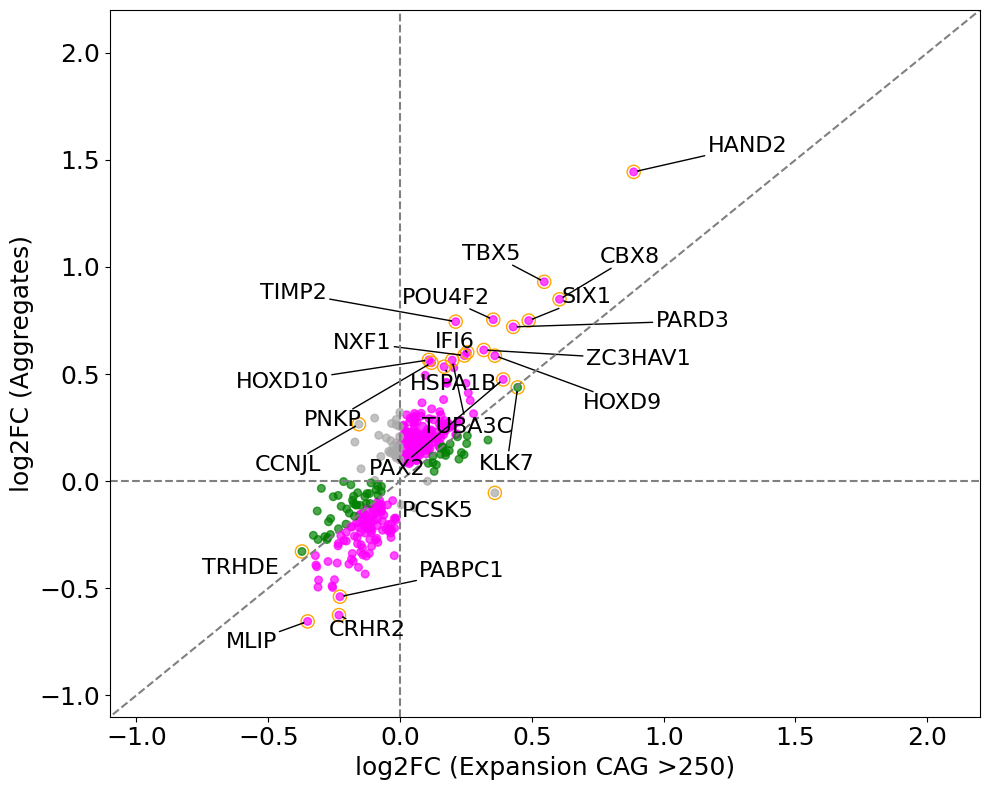

                            OLS Regression Results                            
Dep. Variable:              logFC_Agg   R-squared:                       0.724
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     969.5
Date:                Fri, 21 Aug 2026   Prob (F-statistic):          2.09e-105
Time:                        18:29:06   Log-Likelihood:                 206.24
No. Observations:                 372   AIC:                            -408.5
Df Residuals:                     370   BIC:                            -400.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0556      0.007      7.687      0.0

In [73]:
fc_regression(logfc_cag_ng, logfc_agg_ng, pval_cag_ng, pval_agg_ng, abs_fc=0, res_z=3, topx=10, topy=10, fcx=0.5, fcy=0.53,xlim= (-1.1, 2.2), ylim=(-1.1, 2.2),
              xlabel='log2FC (Expansion CAG >250)',ylabel= 'log2FC (Aggregates)', ptitle='')

In [74]:
##################################################
#### FIGURE 7G: Individual Changes in different populations
##################################################

In [75]:
deg_gn=[
    'HSPA1A','HSPA1B','NXF1','MLIP','PNKP','KLK7','TBX5','HAND2','SIX1','CBX8','PARD3','POU4F2','IFI6','HOXD9','HOXD10','HOXC10','TIMP2','ZC3HAV1','TUBA3C','CRHR2','PABPC1','MYO1E','TRHDE','ATP2A3'
]

In [76]:
adata.obs['Expansion'] = adata.obs['CAG_mut'] >= 150
adata.obs['Expansion_250'] = adata.obs['CAG_mut'] >= 250

In [77]:
adata.obs['Agg'] = adata.obs['Agg'].astype(bool)

adata.obs['Condition_2'] = 'agg-_cag-' 

adata.obs.loc[adata.obs['Agg'], 'Condition_2'] = 'agg+'
adata.obs.loc[(~adata.obs['Agg']) & (adata.obs['Expansion']) & (~adata.obs['Expansion_250']), 'Condition_2'] = 'agg-_cag150+'
adata.obs.loc[(~adata.obs['Agg']) & (adata.obs['Expansion_250']), 'Condition_2'] = 'agg-_cag250+'

adata.obs['Condition_2'] = adata.obs['Condition_2'].astype('category')

In [78]:
adata.obs['Expansion']

Conv_zscan__043_4300113-4-0-0-0     False
Conv_zscan__017_1700121-4-0-0-0     False
Conv_zscan__035_3500197-4-0-0-0      True
Conv_zscan__201_20100036-4-0-0-0    False
Conv_zscan__016_1600014-4-0-0-0     False
                                    ...  
Conv_zscan__213_21300030-2-2-1-1    False
Conv_zscan__010_1000119-2-2-1-1     False
Conv_zscan__009_900068-2-2-1-1      False
Conv_zscan__060_6000066-2-2-1-1     False
Conv_zscan__258_25800047-2-2-1-1     True
Name: Expansion, Length: 12752, dtype: bool

In [79]:
ucondition=adata.obs['Condition_2'].unique()
ucondition

['agg-_cag-', 'agg-_cag250+', 'agg-_cag150+', 'agg+']
Categories (4, object): ['agg+', 'agg-_cag-', 'agg-_cag150+', 'agg-_cag250+']

In [80]:
ucondition_order_2=['agg-_cag-', 'agg-_cag150+', 'agg-_cag250+', 'agg+']
plot_dfs_2 = {}

for gene in deg_gn:
    results = []
    ign = list(good_genes).index(gene)
    adata.obs['expr'] = adata.obsm['X_raw'][:, ign]

    for pt in upatient:
        data_df = adata.obs[['Condition_2', 'expr', 'patient']].copy()
        data_df = data_df[data_df['patient'] == pt].copy()
        data_df['expr'] = pd.to_numeric(data_df['expr'], errors='coerce')
        data_df = data_df.dropna(subset=['Condition_2', 'expr'])

        mean_per_bin = data_df.groupby('Condition_2')['expr'].mean()

        for conditien in ucondition_order_2:
            results.append({
                'patient': pt,
                'Condition_2': conditien,
                'mean_expr': mean_per_bin.get(conditien, np.nan)
            })

    plot_dfs_2[gene] = pd.DataFrame(results)
    print(f"\n{gene}:\n", plot_dfs_2[gene].head())



HSPA1A:
   patient   Condition_2  mean_expr
0      H1     agg-_cag-  21.069351
1      H1  agg-_cag150+  21.400000
2      H1  agg-_cag250+  24.562500
3      H1          agg+  24.295454
4      H2     agg-_cag-   9.560261

HSPA1B:
   patient   Condition_2  mean_expr
0      H1     agg-_cag-  25.824869
1      H1  agg-_cag150+  29.200001
2      H1  agg-_cag250+  30.531250
3      H1          agg+  34.090908
4      H2     agg-_cag-  12.628013

NXF1:
   patient   Condition_2  mean_expr
0      H1     agg-_cag-  16.276358
1      H1  agg-_cag150+  20.311111
2      H1  agg-_cag250+  21.375000
3      H1          agg+  27.500000
4      H2     agg-_cag-  13.403909

MLIP:
   patient   Condition_2  mean_expr
0      H1     agg-_cag-  16.884413
1      H1  agg-_cag150+  15.488889
2      H1  agg-_cag250+  13.781250
3      H1          agg+  11.090909
4      H2     agg-_cag-  20.706188

PNKP:
   patient   Condition_2  mean_expr
0      H1     agg-_cag-   1.094571
1      H1  agg-_cag150+   1.200000
2      H1  

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55353/2029217101.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_per_bin = data_df.groupby('Condition_2')['expr'].mean()
/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55353/2029217101.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_per_bin = data_df.groupby('Condition_2')['expr'].mean()
/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_55353/2029217101.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curre

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


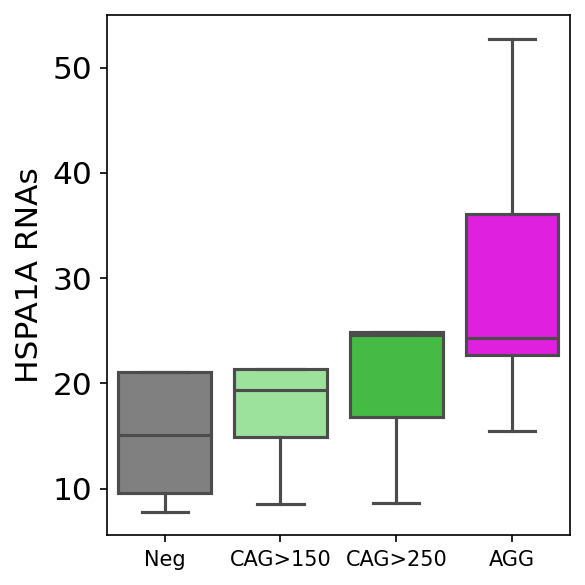

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


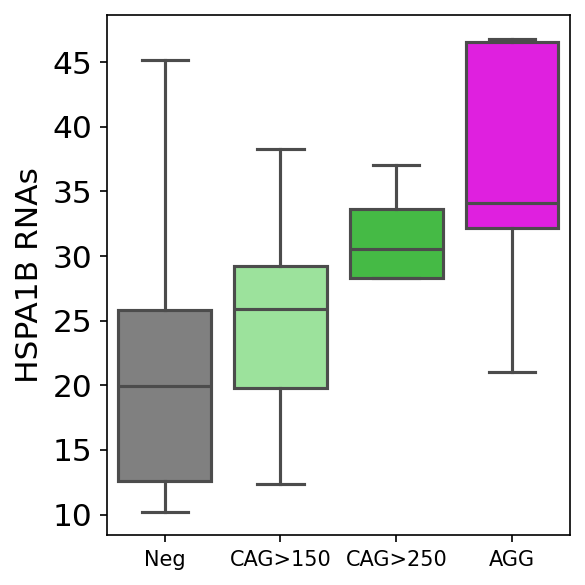

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


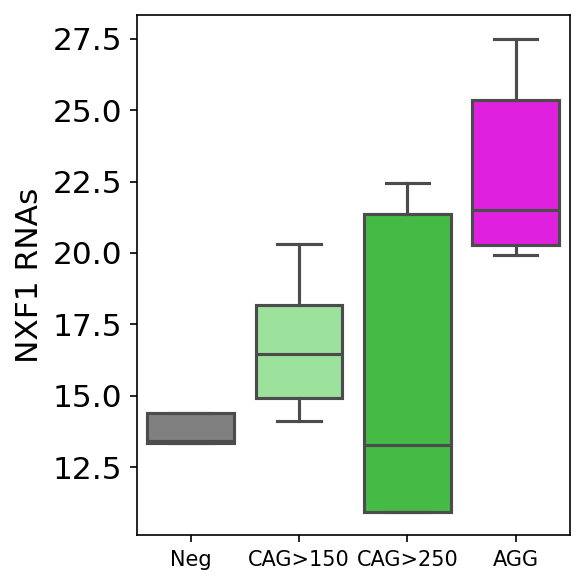

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


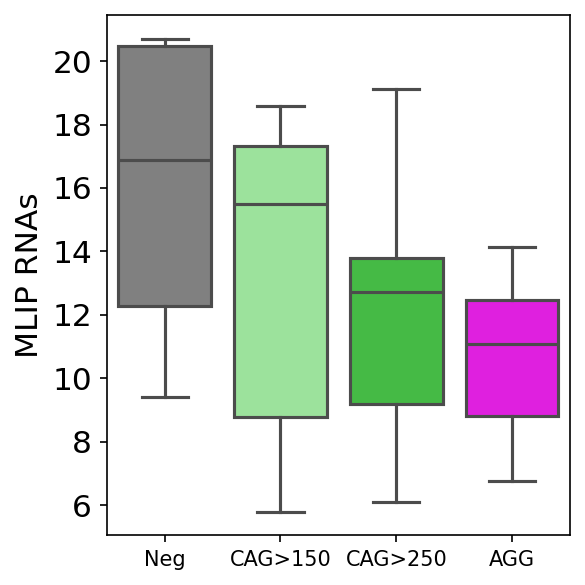

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


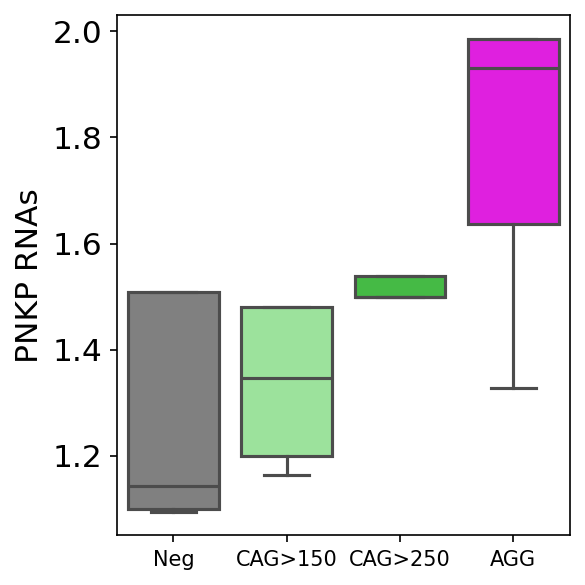

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


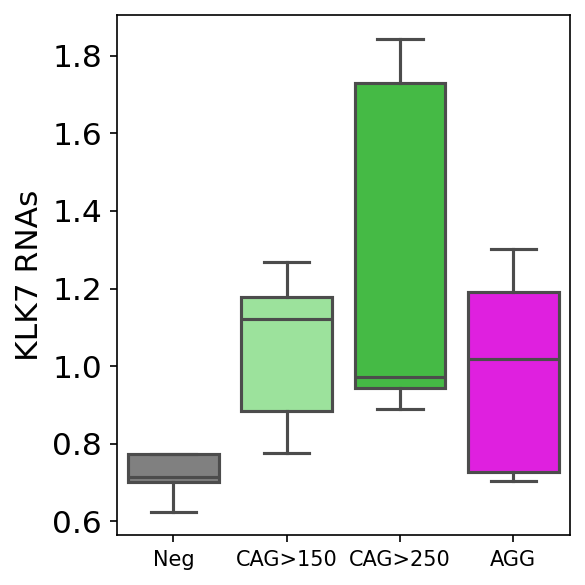

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


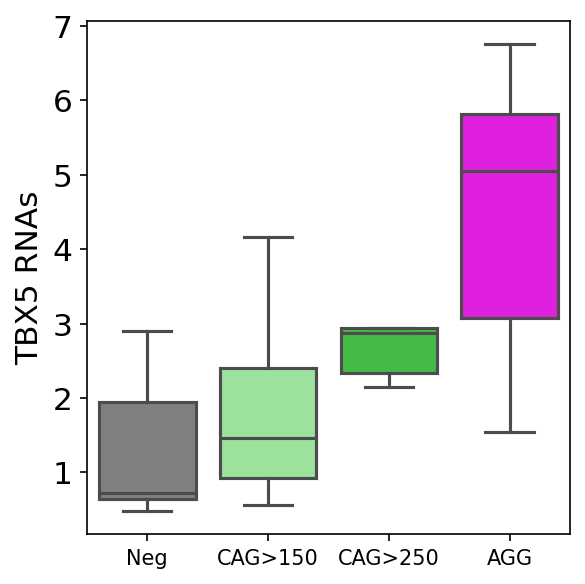

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


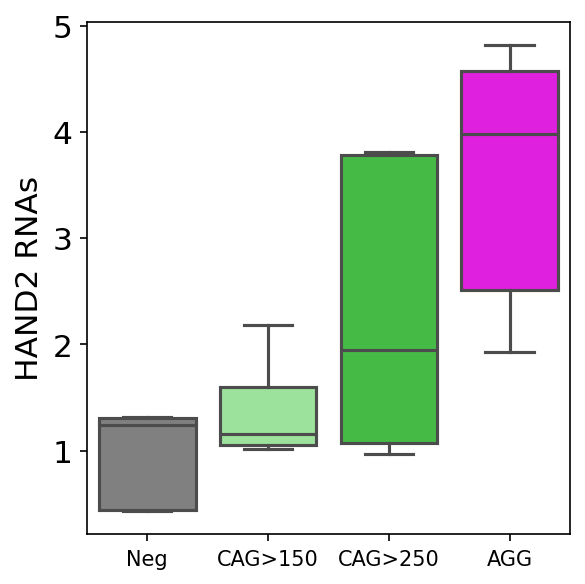

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


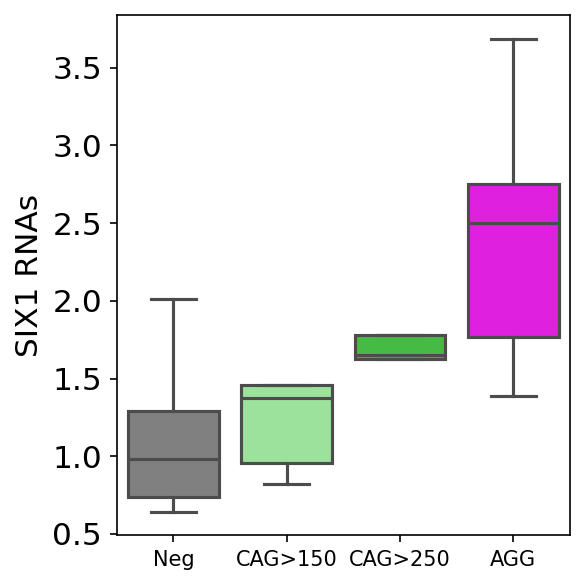

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


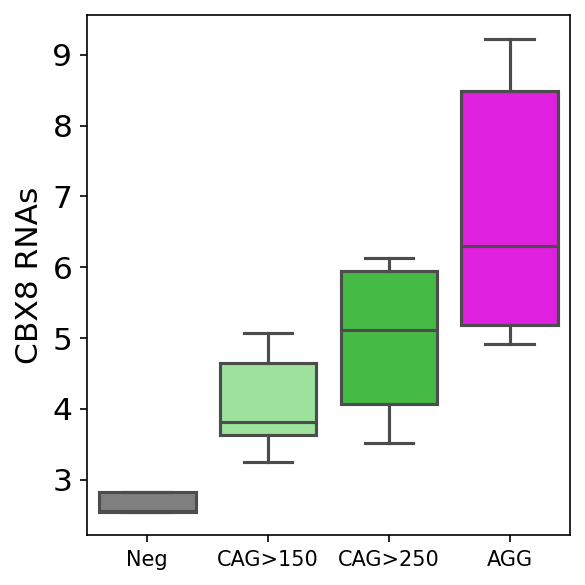

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


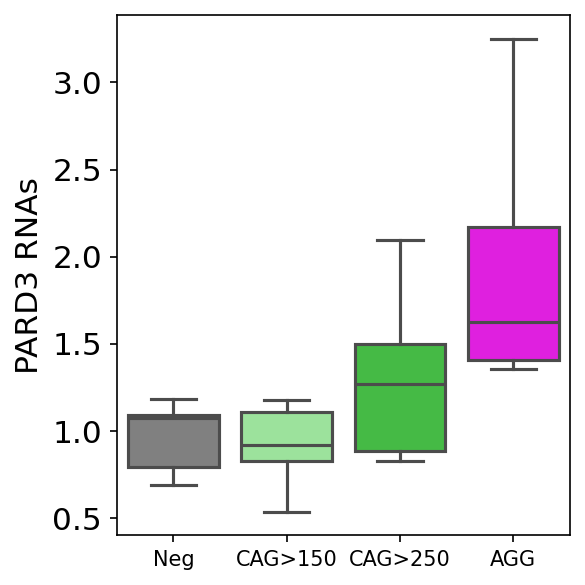

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


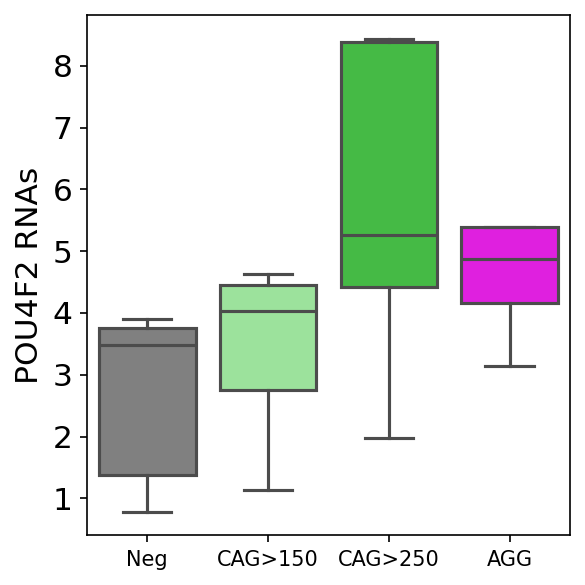

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


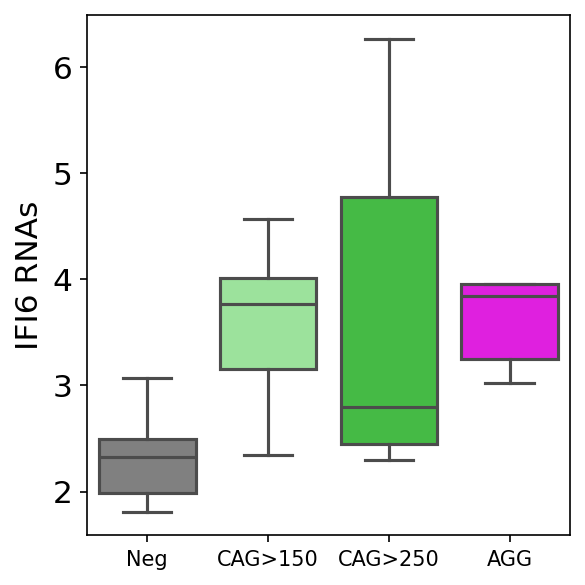

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


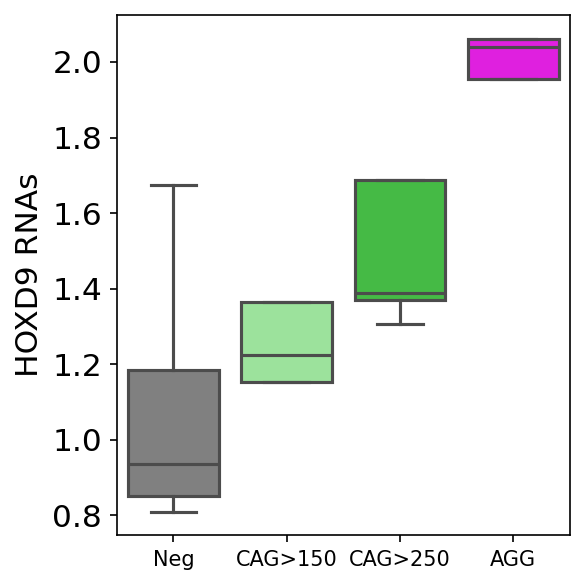

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


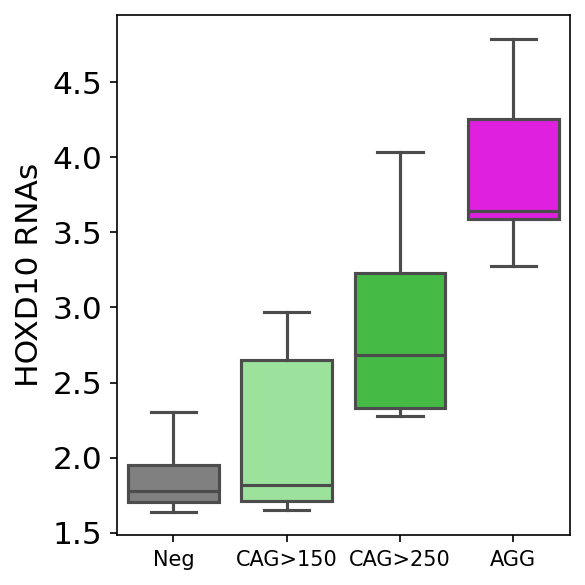

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


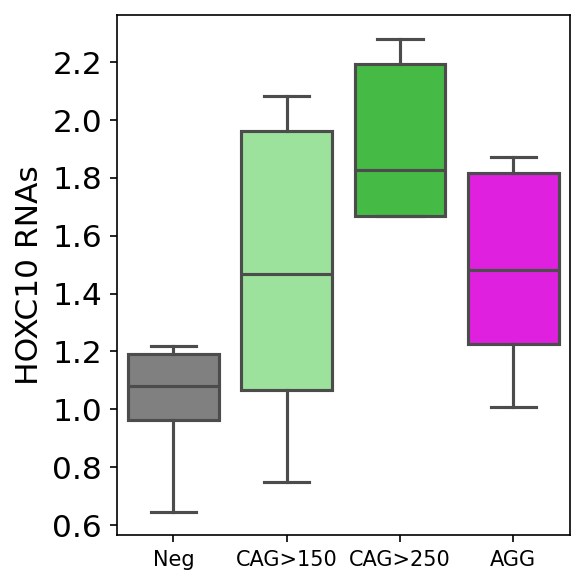

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


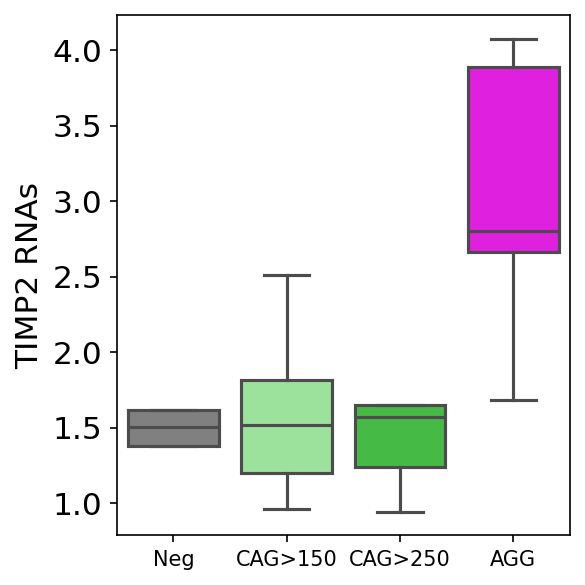

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


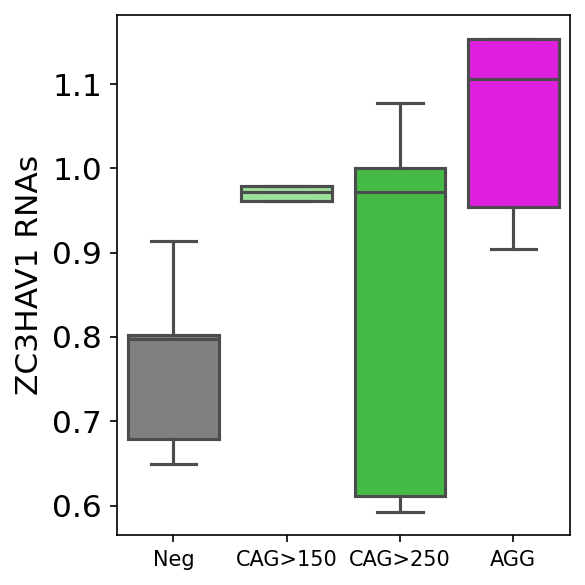

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


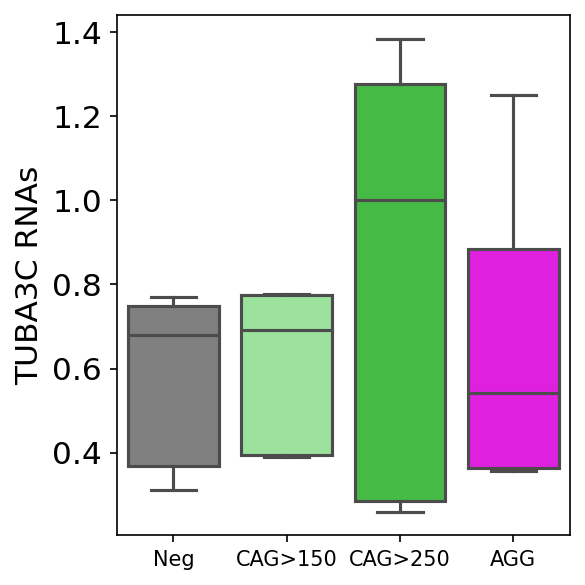

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


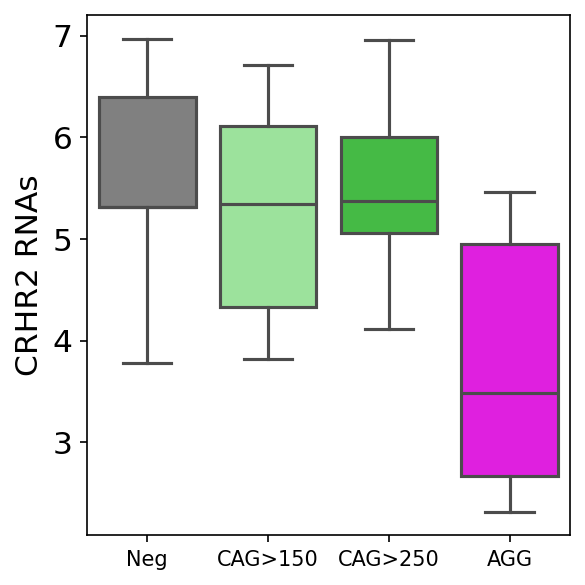

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


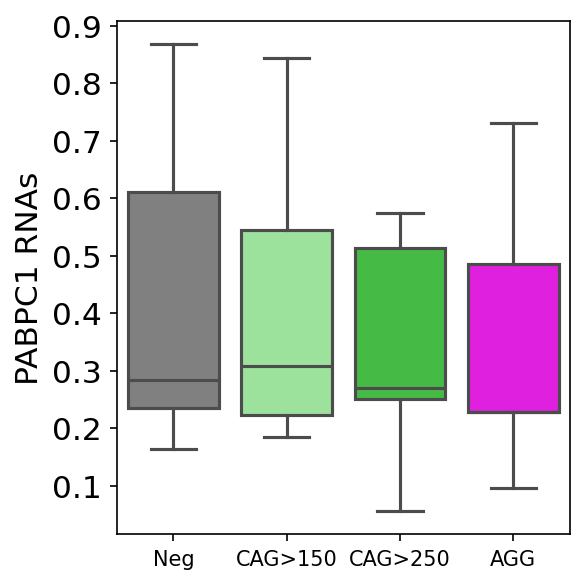

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


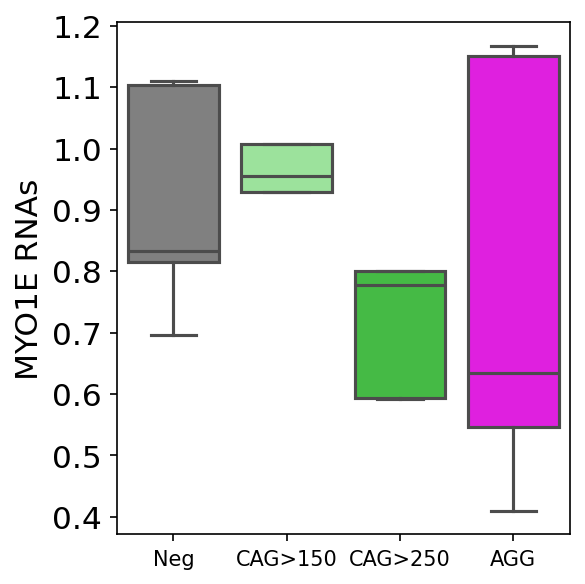

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


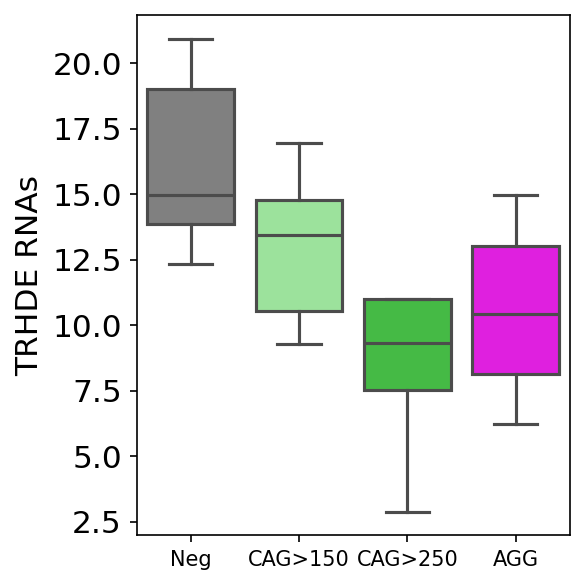

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


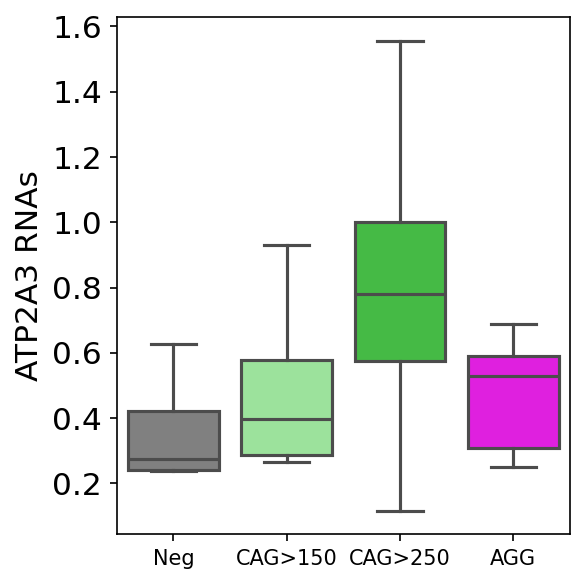

In [81]:
for gn in deg_gn:
    no_path_list = []
    noagg_85_list = []
    noagg_150_list = []
    agg_list = []
    for pt in upatient:
        df_pt = plot_dfs_2[gn]
        df_pt = df_pt[df_pt['patient'] == pt]  

        no_path = df_pt.loc[df_pt['Condition_2'] == 'agg-_cag-', 'mean_expr'].mean()
        noagg_85 = df_pt.loc[df_pt['Condition_2'] == 'agg-_cag150+', 'mean_expr'].mean()
        noagg_150 = df_pt.loc[df_pt['Condition_2'] == 'agg-_cag250+', 'mean_expr'].mean()
        agg_ = df_pt.loc[df_pt['Condition_2'] == 'agg+', 'mean_expr'].mean()

        no_path_list.append(no_path)
        noagg_85_list.append(noagg_85)
        noagg_150_list.append(noagg_150)
        agg_list.append(agg_)

    df_plot = pd.DataFrame({
        'Neg': no_path_list,
        'Exp85': noagg_85_list,
        'Exp150': noagg_150_list,
        'Agg': agg_list,
    }, index=upatient)

    df_plot_melt = df_plot.reset_index().melt(id_vars='index', var_name='Condition_2', value_name='Gene')

    plt.figure(figsize=(4,4), dpi=150)
    ax = sns.boxplot(data=df_plot_melt, x='Condition_2', y='Gene', 
                     showfliers=False, palette=['gray','lightgreen','limegreen','magenta'])


    plt.ylabel(f"{gn} RNAs", fontsize=15)
    plt.xlabel('')
    plt.yticks(fontsize=15)
    plt.xticks([0,1,2,3], ['Neg','CAG>150','CAG>250','AGG'],fontsize=10)
    plt.tight_layout()
    plt.show()
